# Анализ лояльности пользователей Яндекс Афиши

## Цели и задачи проекта

Цель проекта - выявить ключевые факторы, влияющие на повторные заказы пользователей Яндекс Афиши, чтобы маркетинговая команда могла сегментировать аудиторию и настраивать персонализированные предложения. 

Для этого в хподе работы предстоит загрузить и подготовить данные о заказах, провести когортный анализ удержания, изучить поведенческие паттерны лояльных пользователей (тип устройства, регион, категория мероприятия, время между заказами) и визуализировать распределение по частоте покупок и выручке. На основе полученных результатов необходимо сформулировать рекомендации по раннему выявлению перспективных клиентов и оптимизации рекламных бюджетов, оформив выводы в виде отчёта с визуализациями.

## Структура и описание входных данных
В ходе выполнения проекта мы будем работать с базой данных PostgreSQL `data-analyst-afisha`.

Схема `afisha` базы данных `data-analyst-afisha` содержит пять таблиц.

Таблица `purchases`

Содержит информацию о заказах билетов:
- `order_id` — идентификатор заказа;
- `user_id` — идентификатор пользователя, совершившего заказ;
- `created_dt_msk` — дата создания заказа по московскому времени;
- `created_ts_msk` — дата и время создания заказа по московскому времени;
- `event_id` — идентификатор мероприятия из таблицы events;
- `cinema_circuit` — сеть кинотеатров, где проходит мероприятие. Если оно проходит не в кинотеатре, то здесь будет значение нет;
- `age_limit` — возрастное ограничение мероприятия;
- `currency_code` — валюта оплаты;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (например, mobile — мобильные устройства, desktop — компьютеры);
- `revenue` — выручка от заказа;
- `service_name` — название билетного оператора;
- `tickets_count` — количество купленных билетов;
- `total` — общая сумма заказа.

Таблица `events`

Содержит данные о мероприятиях, доступных на платформе:
- `event_id` — идентификатор мероприятия.
- `event_name_code` — название мероприятия в закодированном виде.
- `event_type_description` — описание мероприятия.
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее)
- `organizers` — организаторы мероприятия.
- `city_id` — идентификатор города проведения мероприятия из таблицы cities.
- `venue_id` — идентификатор площадки проведения мероприятия из таблицы venues.

Таблица `venues`

Содержит сведения о площадках проведения мероприятий:
- `venue_id` — идентификатор площадки;
- `venue_name` — название площадки;
- `address` — адрес площадки.

Таблица `city`

Содержит список городов, относящихся к регионам:
- `city_id` — идентификатор города;
- `city_name` — название города;
- `region_id` — идентификатор региона, в котором расположен город, из таблицы regions.

Таблица `regions`

Содержит список регионов, в которых проводятся мероприятия:
- `region_id` — идентификатор региона;
- `region_name` — название региона.

ER-диаграмма, демонстрирующая связи между таблицами:

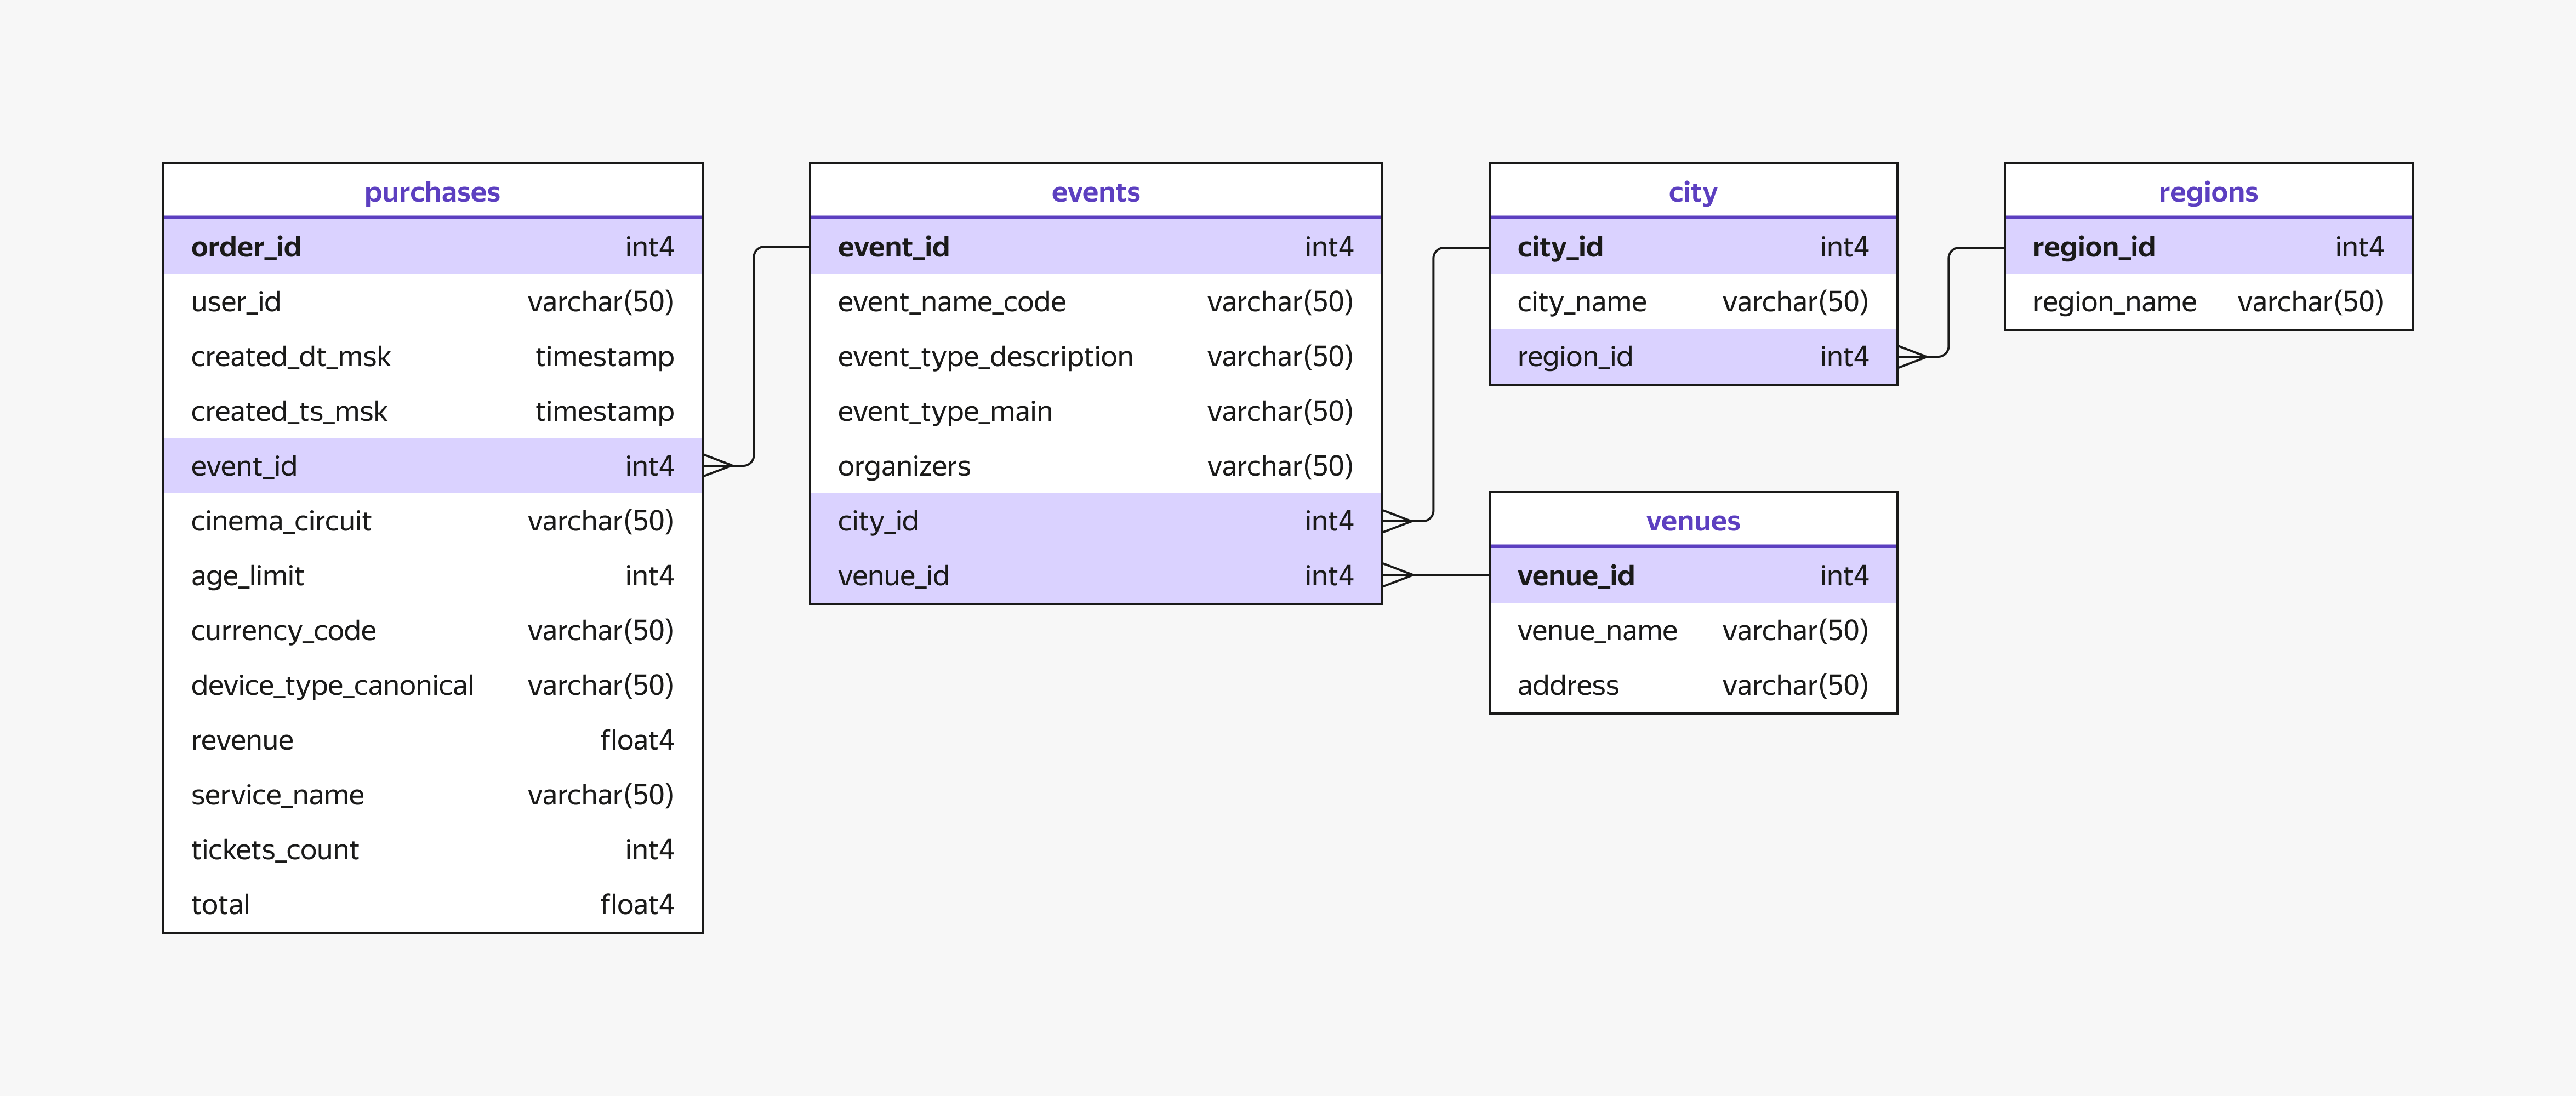

## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

**Задача 1.1:** Напишем SQL-запрос, выгружающий в датафрейм pandas необходимые данные. 

Для начала выполним подключение к базе данных с помощью Python:


In [1]:
#Импортируем необходимые для работы библиотеки
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from phik import phik_matrix
from dotenv import load_dotenv
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

Для подключения к базе данных `data-analyst-afisha` используем следующие параметры :

- **Хост** — `rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net`
- **База данных** — `data-analyst-afisha`
- **Порт** — `6432`
- **Аутентификация** — `Database Native`
- **Пользователь** — `praktikum_student`
- **Пароль** — `Sdf4$2;d-d30pp`



In [2]:
#Запишем эти данные в объект для удобства
#db_config = {'user': 'praktikum_student', # имя пользователя
#             'pwd': 'Sdf4$2;d-d30pp', # пароль
#             'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
#             'port': 6432, # порт подключения
#             'db': 'data-analyst-afisha' # название базы данных
#             }

#Формируем строку для соединения с базой данных
#connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
#    db_config['user'],
#    db_config['pwd'],
#    db_config['host'],
#    db_config['port'],
#    db_config['db'],
#)

load_dotenv()  # загружает переменные из .env

db_config = {
    'user': os.getenv('DB_USER'),
    'pwd': os.getenv('DB_PWD'),
    'host': os.getenv('DB_HOST'),
    'port': os.getenv('DB_PORT'),
    'db': os.getenv('DB_NAME')
}

#Формируем строку для соединения с базой данных
connection_string = URL.create(
    drivername='postgresql',
    username=db_config['user'],
    password=db_config['pwd'],
    host=db_config['host'],
    port=db_config['port'],
    database=db_config['db']
)

#Создаем соединение
engine = create_engine(connection_string)

Теперь выполним извлечение результатов SQL-запроса:

In [3]:
#Пишем запрос к базе данных
query = '''
-- Настройка параметра synchronize_seqscans важна для проверки
WITH set_config_precode AS (
  SELECT set_config('synchronize_seqscans', 'off', true)
)
SELECT 
    user_id,
    device_type_canonical,
    order_id,
    created_dt_msk AS order_dt,
    created_ts_msk AS order_ts,
    currency_code,
    revenue,
    tickets_count,
    EXTRACT(DAY FROM (created_dt_msk - LAG(created_dt_msk) OVER (PARTITION BY user_id ORDER BY created_dt_msk))) AS days_since_prev,
    event_id,
    event_name_code AS event_name,
    event_type_main,
    service_name, 
    region_name,
    city_name
FROM afisha.purchases
LEFT JOIN afisha.events USING (event_id)
LEFT JOIN afisha.city USING (city_id)
LEFT JOIN afisha.regions USING (region_id)
WHERE device_type_canonical IN ('mobile', 'desktop') AND event_type_main != 'фильм'
ORDER BY user_id
'''

In [4]:
#Результат выдачи SQL-запроса запишем в датафрейм
df = pd.read_sql_query(query, con=engine)

In [5]:
#Проверим датафрейм и выведем первые 5 строк
df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк


Выгрузка из базы данных SQL позволяет собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---

---

**Задача 1.2:** Изучим общую информацию о выгруженных данных. Оценим корректность выгрузки и объём полученных данных.

Предположим, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируем основную информацию о данных в кратком промежуточном выводе.

---

In [6]:
#Посмотрим на результат вывода метода info 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

In [7]:
#Абсолютное число пропусков в столбце days_since_prev
df['days_since_prev'].isna().sum()

np.int64(21933)

In [8]:
#Относительное число пропусков в столбце days_since_prev 
round(df['days_since_prev'].isna().mean(), 4)

np.float64(0.0755)

Отметим, что в данных `290 611` строк и `15` столбцов с данными.

Пропускии встречаются только в одном столбце: `days_since_prev`. Всего пропусков в этом столбце `21 933` (примерно `7.5%` от общего числа).Мы знаем о происхождении этих пропусков: они связаны с тем, что у пользователя была совершена всего одна покупка, т.е. нет разницы между текущей и предыдущей покупкой. Зная эту информацию, с этими пропусками ничего не надо делать: ни удалять, ни заменять.

Все типы данных датафрейма соответствуют содержимому столбцов и не нуждаются в дополнительной корректировке.

---

###  2. Предобработка данных

Выполним все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведем выручку к единой валюте — российскому рублю.

Для этого используем датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его загрузим по пути `'https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv'` (значения в рублях представлено для 100 тенге)

Результаты преобразования сохраним в новый столбец `revenue_rub`.

---


In [9]:
#Загружаем датафрейм
df_currency = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

In [10]:
#Смотрм на его содержимое
df_currency.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [11]:
#Посмотрим детальнее на типы данных и проруски
df_currency.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


Поскольку тип данных в столбце `data` - `object`, приведем его к типу `datetime`, чтобы можно было объеденить датафреймы для пересчета валют.

Кроме того, в данных присутствуют данные по 357 дням из 366. Надо будет убедиться, что данные есть по всем дням из интересующего нас интервала.

In [12]:
#Приводим столбец data к типу datetime
df_currency['data'] = pd.to_datetime(df_currency['data'])

In [13]:
#Объединяем датафреймы (только столбцы с датой и курсом)
df = df.merge(df_currency[['data', 'curs']], left_on='order_dt', right_on='data', how='left')

In [14]:
#Копируем столбец revenue в revenue_rub
df['revenue_rub'] = df['revenue']

#Маска для заказов в тенге для читаемости
mask_kzt = df['currency_code'] == 'kzt'

#Пересчёт для тенге
df.loc[mask_kzt, 'revenue_rub'] = df.loc[mask_kzt, 'revenue'] * df.loc[mask_kzt, 'curs'] / 100

In [15]:
#Проверим, для всех ли дат из необходимого диапазона был дан курс
df['revenue_rub'].isna().sum()

np.int64(0)

In [16]:
#Посмотрим на датафрейм после преобразований
df[df['currency_code'] == 'kzt'].head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name,data,curs,revenue_rub
70,0033403583a55ed,mobile,7850214,2024-09-17,2024-09-17 16:52:06,kzt,518.10,4,20.0,559919,f5ec2467-ee48-42f3-89a0-a2d90d1d6fce,другое,Билеты без проблем,Верхоречная область,Серебрянка,2024-09-17,19.0125,98.503762
89,0040e12d70fae81,desktop,8634925,2024-09-02,2024-09-02 19:49:14,kzt,347.18,3,39.0,559476,61ec7c0e-ea0c-4a3e-a63a-09cbe1bc6177,другое,Билеты без проблем,Верхоречная область,Серебрянка,2024-09-02,18.9330,65.731589
96,0054b38b2653e6e,mobile,7625522,2024-09-09,2024-09-09 18:06:04,kzt,328.77,4,NaN,559582,524f434e-0381-4f47-9688-7c4e41961b65,другое,Билеты без проблем,Верхоречная область,Серебрянка,2024-09-09,18.5991,61.148261
277,00f4f5244501ce6,mobile,720419,2024-06-11,2024-06-11 20:15:57,kzt,22021.55,5,NaN,536826,76af4f88-c554-4e9e-9df4-1cc8aeec8959,концерты,Мой билет,Верхоречная область,Серебрянка,2024-06-11,19.8928,4380.702898
460,01370a0e9c1a7d5,desktop,5227657,2024-06-04,2024-06-04 13:28:17,kzt,7397.66,4,1.0,533803,0686ac7b-6f3e-4177-bb73-16b54acd1223,концерты,Мой билет,Шанырский регион,Широковка,2024-06-04,19.9833,1478.296591


Было выполнено объединение с таблицей курсов  валют: в датафрейм добавлен столбец `curs` (и столбец `data` как ключ), а затем пересчитана выручка в рубли (новый столбец `revenue_rub`). Пропусков в новом столбце не обнаружено, значит, для всех дат заказов присутствует соответствующий курс тенге.

---

**Задача 2.2:**

- Изучим значения в ключевых столбцах. Обработаем ошибки, если обнаружим их.
    - Проверим, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведем нормализацию данных, если это будет необходимо.
    - Проверим распределение численных данных и наличие в них выбросов. Для этого используем статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверим данные в этих столбцах.
        
        Если обнаружим выбросы в поле `revenue_rub`, то отфильтруем значения по 99 перцентилю.

После предобработки проверьим, были ли отфильтрованы данные. Если были, то оцении, в каком объёме. Сформулируем промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

Для начала проверим уникальные названия в столбцах с категориальными данными, чтобы убедиться в отсутствии неявных дубликатов или других значений, которых там быть не должно:

In [17]:
df['device_type_canonical'].unique()

array(['mobile', 'desktop'], dtype=object)

In [18]:
df['currency_code'].unique()

array(['rub', 'kzt'], dtype=object)

In [19]:
df['event_type_main'].unique()

array(['театр', 'выставки', 'другое', 'стендап', 'концерты', 'спорт',
       'ёлки'], dtype=object)

In [20]:
df['service_name'].unique()

array(['Край билетов', 'Мой билет', 'За билетом!', 'Лови билет!',
       'Билеты без проблем', 'Облачко', 'Лучшие билеты', 'Прачечная',
       'Быстробилет', 'Дом культуры', 'Весь в билетах', 'Билеты в руки',
       'Тебе билет!', 'Show_ticket', 'Городской дом культуры', 'Яблоко',
       'Билет по телефону', 'Выступления.ру', 'Росбилет',
       'Шоу начинается!', 'Мир касс', 'Восьмёрка', 'Телебилет',
       'Crazy ticket!', 'Реестр', 'Быстрый кассир', 'КарандашРУ',
       'Радио ticket', 'Дырокол', 'Вперёд!', 'Кино билет', 'Цвет и билет',
       'Зе Бест!', 'Тех билет', 'Лимоны', 'Билеты в интернете'],
      dtype=object)

In [21]:
df['region_name'].unique()

array(['Каменевский регион', 'Североярская область', 'Озернинский край',
       'Лугоградская область', 'Поленовский край', 'Широковская область',
       'Медовская область', 'Златопольский округ', 'Малиновоярский округ',
       'Яблоневская область', 'Ветренский регион', 'Боровлянский край',
       'Крутоводская область', 'Ягодиновская область',
       'Серебряноярский округ', 'Лесодальний край', 'Верхоречная область',
       'Горицветская область', 'Речиновская область', 'Травиницкий округ',
       'Сосновская область', 'Серебринская область', 'Травяная область',
       'Каменноярский край', 'Солнечноземская область',
       'Светополянский округ', 'Заречная область', 'Ручейковский край',
       'Глиногорская область', 'Тепляковская область',
       'Каменноозёрный край', 'Солнечнореченская область',
       'Зоринский регион', 'Берёзовская область', 'Лесостепной край',
       'Малиновая область', 'Синегорский регион', 'Луговая область',
       'Шанырский регион', 'Каменополянский окр

In [22]:
df['city_name'].unique()

array(['Глиногорск', 'Озёрск', 'Родниковецк', 'Кристалевск',
       'Дальнозолотск', 'Радужнополье', 'Радужсвет', 'Кумсай',
       'Верховино', 'Светополье', 'Кокжар', 'Каменский', 'Лесоярич',
       'Никольянов', 'Речинцево', 'Лесозолотск', 'Дальнозерск',
       'Серебрянка', 'Островецк', 'Родниковец', 'Дальнесветск',
       'Луговаярово', 'Дальнополин', 'Ягодиновка', 'Солчелуг', 'Озёрчане',
       'Серебровино', 'Лесоярово', 'Глинополье', 'Глиноград',
       'Дальнесветин', 'Северополье', 'Теплоозеро', 'Горнодолинск',
       'Ордакент', 'Озёрово', 'Луговинск', 'Лугоград', 'Златопольск',
       'Крутовинск', 'Сарыжар', 'Сосновечин', 'Тихоярск', 'Яблонецк',
       'Жаркентай', 'Широковка', 'Синеводов', 'Синеводск', 'Тихосветск',
       'Радужанов', 'Глиногорь', 'Каменосветск', 'Родниковск',
       'Травогород', 'Глинянск', 'Радужинск', 'Поляногорье',
       'Дальнолесье', 'Ручейник', 'Ключеград', 'Ключеводск', 'Поленовино',
       'Речичанск', 'Ключевополье', 'Шаныртау', 'Дальнесоснов'

Заметим, что в данных отсутствуют неявные дубликаты, а также  категории, обозначающие пропуски в данных или отсутствие информации, не считая `NULL` в колонке `days_since_prev`.

Теперь изучим столбец `tickets_count` и посмотрим на распределение данных в нем:

In [23]:
#Получаем описательную статистику по столбцу
df['tickets_count'].describe()

count    290611.000000
mean          2.754311
std           1.170620
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          57.000000
Name: tickets_count, dtype: float64

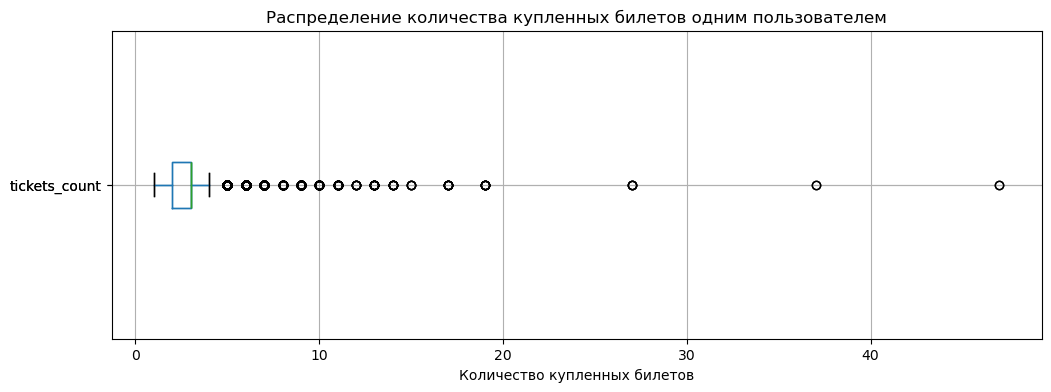

In [120]:
#Строим диаграмму размаха
df.boxplot(column = 'tickets_count', 
           figsize = (12, 4),
           vert = False)

plt.title('Распределение количества купленных билетов одним пользователем')
plt.xlabel('Количество купленных билетов')

plt.show()

По получившимуся графику и описательной статистике заметим, что большая часть данных распределена в пределах от 1 до 4 билетов на пользователя (покупка себе/в подарок/всей семье/компании), среднее значение близко к 3, а среднеквадратичное отклонение бизко к единице, что говорит о небольшом разбросе данных. Однако эти значения смещены из-за наличия выбросов.

Также в данных присутствует небольшое количество выбросов, что смещает оценки. Например, максимальное количетво купленных билетов одним пользователем равно 57. Однако скорее всего это не ошибка, а ситуация, когда билеты покупались какому-либо большому коллективу, группе или классу (совместный поход с классом в театр, корпоратив или масштабный праздник). Следовательно, значения в этих данных корректны.

Теперь изучим столбец `revenue_rub`:

In [25]:
#Получаем описательную статистику по столбцу
df['revenue_rub'].describe()

count    290611.000000
mean        555.571987
std         875.498172
min         -90.760000
25%         113.970000
50%         351.140000
75%         802.050000
max       81174.540000
Name: revenue_rub, dtype: float64

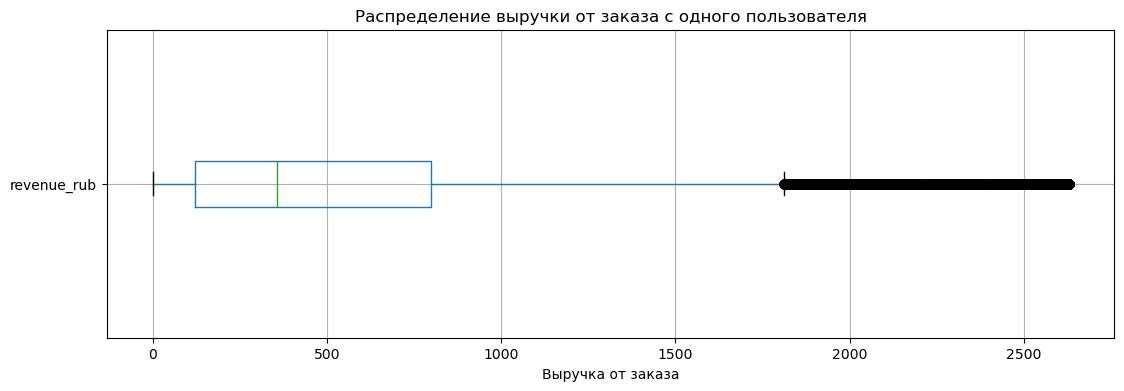

In [117]:
#Строим диаграмму размаха
df.boxplot(column = 'revenue_rub', 
           figsize = (13, 4),
           vert = False)

plt.title('Распределение выручки от заказа с одного пользователя')
plt.xlabel('Выручка от заказа')

plt.show()

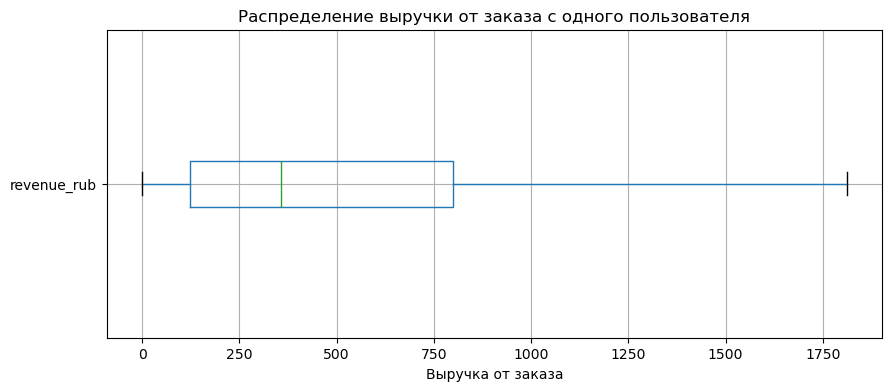

In [116]:
#Посмотрим на диаграмму размаха без выбросов
df.boxplot(column='revenue_rub',
           figsize=(10,4),
           showfliers=False,
           vert = False)

plt.title('Распределение выручки от заказа с одного пользователя')
plt.xlabel('Выручка от заказа')

plt.show()

Заметим, что большая часть значений находится в диапазоне от `100` до `800` рублей, а среднее равно `555` рублей. При этом среднеквадратичное отклонение в этом случае уже больше: `875` рублей, что говорит о большей вариативности данных.

В данных так же присутствует большое количество выбросов, например, максимальная выручка с заказа равна `81 174` руб. Это абсолютно закономерно, поскольку такими суммами могли оплачиваться те самые заказы с большим количеством билетов. Кроме того, не редко стоят больших денег и билеты в театры или на концерты, особенно если артисты зарубежные.

Помимо этого в данных замечены значения с отрицательной выручкой. Возможно, если в данных учтены возвраты денег клиентам, то выручка может быть отрицательной. Например, при отмене заказа сумма возвращается, и в системе это может фиксироваться как отрицательная выручка. Либо же это может оказатьсся ошибкой в данных.

Чтобы сильно не искажать данные бльшими значениями, отфильтруем их по 99 процентилю и исключим данные с отрицательной выручкой, поскольку они нас не интересуют:

In [28]:
# Отбираем только заказы с положительной выручкой
positive_revenue = df['revenue_rub'][df['revenue_rub'] > 0]

# Вычисляем 99-й процентиль
threshold = positive_revenue.quantile(0.99)

# Применяем фильтр к основному датафрейму
df = df[(df['revenue_rub'] > 0) & (df['revenue_rub'] <= threshold)]

In [29]:
df.shape

(281879, 18)

После фильтации мы получили `281 879` строк датафрейма вместо `290 611` (удалено `8 732` строк или `3%` от общего числа строк).

Теперь рассмотрим столбец `days_since_prev`:

In [30]:
#Получаем описательную статистику по столбцу
df['days_since_prev'].describe()

count    260497.000000
mean          3.251734
std          11.417150
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max         148.000000
Name: days_since_prev, dtype: float64

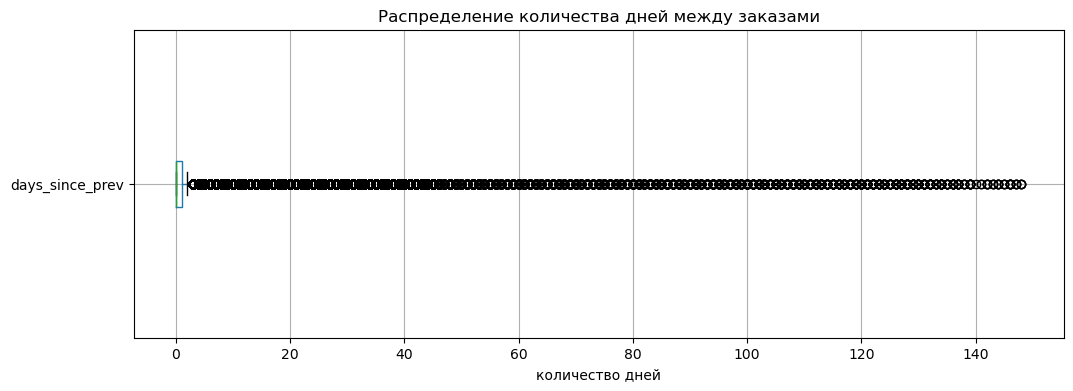

In [115]:
#Строим диаграмму размаха
df.boxplot(column = 'days_since_prev', 
           figsize = (12, 4),
           vert = False)

plt.title('Распределение количества дней между заказами')
plt.xlabel('количество дней')

plt.show()

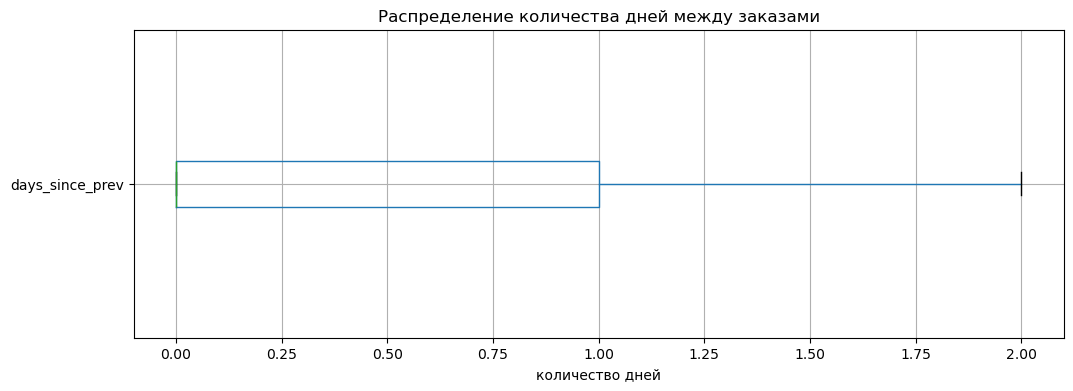

In [114]:
#Строим диаграмму размаха без выбросов
df.boxplot(column = 'days_since_prev', 
           figsize = (12, 4),
           vert = False,
           showfliers = False)

plt.title('Распределение количества дней между заказами')
plt.xlabel('количество дней')

plt.show()

In [33]:
df['days_since_prev'].isna().sum()

np.int64(21382)

Распределение дней между покупками показывает, что медиана равна `0` дней, а среднее составляет `3.25` дня (без учета `NULL`, т.е. `21 382` пользователей так и не совершили повторной покупки). Это говорит о том, что большинство пользователей, совершающих повторные покупки, делают это либо в тот же день, либо на следующий день (более `75%` пользователей возвращаются в течение одного дня). При этом есть и длинные интервалы - до `148` дней, что формирует правый "хвост" распределения. Наличие большого количества выбросов на диаграмме размаха объясняется тем, что основная масса значений сконцентрирована у нуля, а редкие длительные промежутки сильно растягивают шкалу. Это типично для данных о повторных покупках: большинство возвращается быстро, но небольшая часть пользователей пропадает на длительный срок и затем возвращается. Для дальнейшего анализа стоит либо оставить данные как есть (чтобы видеть реальную картину), либо сгруппировать интервалы в категории (например, 0-1 день, 2-7 дней, более 7 дней) для более удобной интерпретации.

Таким образом, в ходе предобработки выручка приведена к рублям: для заказов в тенге использован курс из внешнего датасета, пропусков не возникло. Категориальные данные не содержат неявных дубликатов. Количество билетов в заказе варьируется от `1` до `57`, медиана — `3`. Для выручки исключены отрицательные значения (вероятно, возвраты) и выбросы выше `99`-го процентиля, что позволило удалить около 3% записей. Пропуски в days_since_prev (`21 382`) соответствуют пользователям с одной покупкой; у остальных медиана интервала между заказами равна `0` дней, а `75%` повторных покупок происходят в течение суток. 

---

### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Построим профиль пользователя — для каждого пользователя найдем:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавим два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируем данные по времени совершения заказа.

---


In [34]:
# Сортируем данные по дате и времени заказа
df_sorted = df.sort_values(['order_dt', 'order_ts'])

# Строим профиль пользователя
user_profile = df_sorted.groupby('user_id').agg(
    first_order_dt=('order_dt', 'first'),
    last_order_dt=('order_dt', 'last'),
    first_device=('device_type_canonical', 'first'),
    first_region=('region_name', 'first'),
    first_service=('service_name', 'first'),
    first_event_type=('event_type_main', 'first'),
    total_orders=('order_id', 'count'),
    avg_revenue=('revenue_rub', 'mean'),
    avg_tickets=('tickets_count', 'mean'),
    avg_days_between=('days_since_prev', 'mean')
).reset_index()

# Добавляем бинарные признаки
user_profile['is_two'] = user_profile['total_orders'] >= 2
user_profile['is_five'] = user_profile['total_orders'] >= 5

In [35]:
#Выведем результат
user_profile

,user_id,first_order_dt,last_order_dt,first_device,first_region,first_service,first_event_type,total_orders,avg_revenue,avg_tickets,avg_days_between,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,1521.940000,4.000000,NaN,False,False
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,Каменевский регион,Мой билет,выставки,2,774.010000,3.000000,75.000,True,False
2,000898990054619,2024-07-13,2024-10-23,mobile,Североярская область,Лови билет!,другое,3,767.213333,2.666667,51.000,True,False
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,Каменевский регион,Край билетов,театр,1,917.830000,4.000000,NaN,False,False
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,Поленовский край,Лучшие билеты,театр,2,61.310000,1.500000,16.000,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
21695,fff13b79bd47d7c,2024-07-16,2024-10-31,mobile,Каменевский регион,Мой билет,другое,9,688.043333,2.555556,13.375,True,True
21696,fff32fc9ad0f9f6,2024-08-15,2024-10-28,desktop,Каменевский регион,Билеты без проблем,стендап,2,850.995000,2.500000,74.000,True,False
21697,fffcd3dde79eb2c,2024-06-20,2024-10-30,desktop,Каменевский регион,Билеты без проблем,концерты,33,557.908485,2.787879,4.125,True,True
21698,fffeeb3c120cf0b,2024-09-24,2024-09-24,desktop,Широковская область,Билеты без проблем,стендап,1,661.530000,2.000000,NaN,False,False


In [36]:
#Посмотрим информацию о получившемся датафрейме
user_profile.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21700 entries, 0 to 21699
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           21700 non-null  object        
 1   first_order_dt    21700 non-null  datetime64[ns]
 2   last_order_dt     21700 non-null  datetime64[ns]
 3   first_device      21700 non-null  object        
 4   first_region      21700 non-null  object        
 5   first_service     21700 non-null  object        
 6   first_event_type  21700 non-null  object        
 7   total_orders      21700 non-null  int64         
 8   avg_revenue       21700 non-null  float64       
 9   avg_tickets       21700 non-null  float64       
 10  avg_days_between  13457 non-null  float64       
 11  is_two            21700 non-null  bool          
 12  is_five           21700 non-null  bool          
dtypes: bool(2), datetime64[ns](2), float64(3), int64(1), object(5)
memory usage:

---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными мы работаем: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитаем:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучим статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оценим данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если найдём аномальные значения, опишием их и примим обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если проведём фильтрацию, то вычислим объём отфильтрованных данных и выведем статистические показатели по обновлённому датасету.

In [37]:
#Общее число пользователей в выборке
user_profile['user_id'].count()

np.int64(21700)

In [38]:
#Средняя выручка с 1 заказа
round(user_profile['avg_revenue'].mean(), 4)

np.float64(551.879)

In [39]:
#Доля пользователей с 2 заказами и более
round(user_profile['is_two'].sum()/user_profile['user_id'].count(), 4)

np.float64(0.6167)

In [40]:
#Доля пользователей с 5 заказами и более
round(user_profile['is_five'].sum()/user_profile['user_id'].count(), 4)

np.float64(0.2887)

Общее число пользователей в выборке составляет `21 700`, что является достаточным объёмом для статистически значимых выводов. Средняя выручка с одного заказа равна `551.88` руб., что соответствует ранее полученным данным. Доля пользователей, совершивших два и более заказа, составляет `61.67%`, а пять и более — `28.87%`. Это говорит о том, что значительная часть аудитории возвращается на платформу, причём каждый четвёртый пользователь совершает не менее пяти покупок. Однако для полноты оценки необходимо дополнительно изучить распределение общего числа заказов и среднего количества билетов — если будут обнаружены экстремальные выбросы, их стоит либо оставить, если это реальные супер-лояльные клиенты, либо отфильтровать по 99-му процентилю, чтобы не искажать средние показатели. 

Далее рассмотрим статистические показатели по общему числу заказов:

In [41]:
user_profile['total_orders'].describe()

count    21700.000000
mean        12.989816
std        119.766778
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max       9987.000000
Name: total_orders, dtype: float64

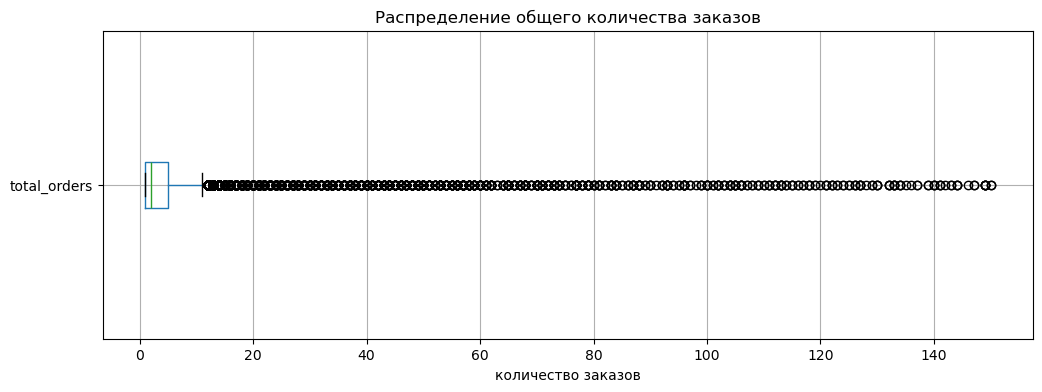

In [113]:
#Строим диаграмму размаха
user_profile.boxplot(
    column = 'total_orders', 
    figsize = (12, 4),
    vert = False)

plt.title('Распределение общего количества заказов')
plt.xlabel('количество заказов')

plt.show()

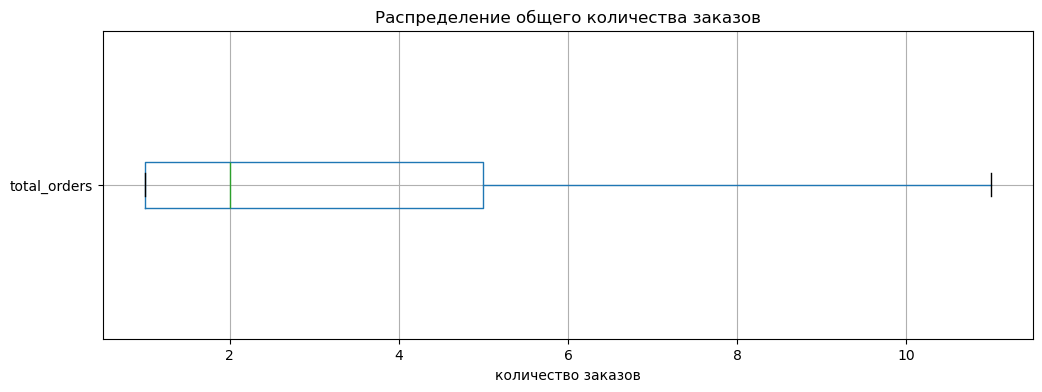

In [112]:
#Строим диаграмму размаха без выбросов
user_profile.boxplot(
    column = 'total_orders', 
    figsize = (12, 4),
    vert = False,
    showfliers = False)

plt.title('Распределение общего количества заказов')
plt.xlabel('количество заказов')

plt.show()

Распределение общего числа заказов на одного пользователя демонстрирует сильную правостороннюю асимметрию: медиана составляет всего `2` заказа, тогда как среднее значение достигает `12.99`, а максимальное зафиксировано на уровне `9987` заказов. Такое расхождение указывает на присутствие небольшой группы пользователей, которые совершают сотни и даже тысячи покупок. Эти аномалии могут быть следствием корпоративных закупок, деятельности перекупщиков билетов, использования технических аккаунтов или ботов, а также возможных ошибок в учёте. Чтобы исключить искажение показателей, отфильтруем данные по 99-му процентилю. В то же время выявленная группа сверхактивных клиентов представляет интерес для отдельного анализа, так как может обеспечивать существенную долю выручки.

In [44]:
# Отфильтруем по 99 процентиилю
threshold = user_profile['total_orders'].quantile(0.99)
user_profile = user_profile[user_profile['total_orders'] <= threshold]

In [45]:
#Посмотрим, пользователей с каким числом заказов удалили из выборки
threshold

np.float64(150.0099999999984)

In [46]:
#Оценим размеры получившегося датафрейма
user_profile.shape

(21483, 13)

Отметим, что всего удалено было `217` пользователей (`~1%`), у которых число покупок было более `150`. Однако их присутствие важно учитывать при сегментации аудитории: возможно, именно эти пользователи приносят значительную долю выручки, и их стоит изучать отдельно. 

Теперь рассмотрим статистические показатели по среднему числу билетов:

In [47]:
user_profile['avg_tickets'].describe()

count    21483.000000
mean         2.746183
std          0.918756
min          1.000000
25%          2.000000
50%          2.750000
75%          3.111111
max         11.000000
Name: avg_tickets, dtype: float64

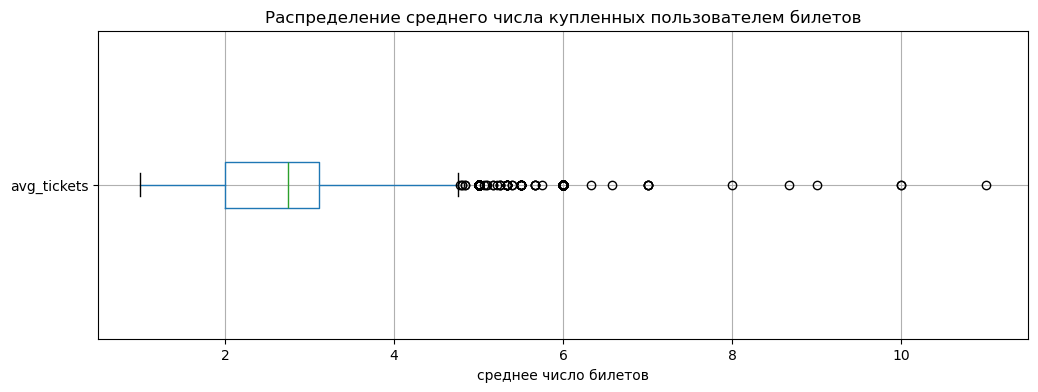

In [111]:
#Строим диаграмму размаха
user_profile.boxplot(
    column = 'avg_tickets', 
    figsize = (12, 4),
    vert = False)

plt.title('Распределение среднего числа купленных пользователем билетов')
plt.xlabel('среднее число билетов')

plt.show()

Среднее число билетов в заказе на пользователя составляет около `2.75` при медиане `2.75`, что указывает на симметричное распределение без выраженных перекосов (без учета выбросов). Большинство пользователей покупают от `2` до `3` билетов за раз, максимум достигает `11` билетов, что является редким, но не аномальным значением. Таким образом, данные по количеству билетов не содержат существенных выбросов и не требуют дополнительной фильтрации, а полученные показатели отражают типичное поведение покупателей, которые приобретают билеты для себя или в компании до `3` человек.

Теперь рассмотрим статистические показатели по среднему числу дней между покупками:

In [49]:
user_profile['avg_days_between'].describe()

count    13240.000000
mean        16.153980
std         22.435742
min          0.000000
25%          1.333333
50%          8.394444
75%         21.000000
max        148.000000
Name: avg_days_between, dtype: float64

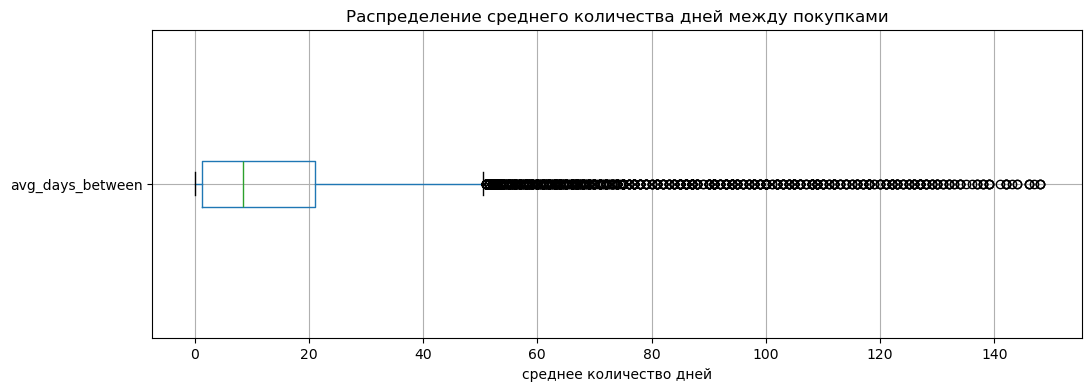

In [110]:
#Строим диаграмму размаха
user_profile.boxplot(
    column = 'avg_days_between', 
    figsize = (12, 4),
    vert = False)

plt.title('Распределение среднего количества дней между покупками')
plt.xlabel('среднее количество дней')

plt.show()

Среднее время между заказами на одного пользователя составляет `16.15` дней при медиане `8.39` дней, что говорит о значительном разбросе данных и наличии выбросов с большими интервалами (до `148` дней). Основная масса пользователей возвращается в течение трёх недель (75% имеют средний интервал до `21` дня), но наблюдается длинный хвост из тех, кто делает повторные покупки с большими перерывами, что согласуется с ранее выявленным правым смещением в распределении `days_since_prev`. Наличие большого количества выбросов на диаграмме размаха не является аномалией, а отражает естественное разнообразие поведения пользователей: одни возвращаются часто (в пределах недели), другие — с заметными промежутками. Для дальнейшего анализа такие выбросы лучше не удалять, так как они несут информацию о различных сегментах аудитории.

Важно отметить, что в отличие от столбца `days_since_prev`, где нулевые значения соответствовали отдельным парам заказов в один день, в профиле пользователя усреднение по всем парам заказов приводит к тому, что нулевые интервалы встречаются только у пользователей, все заказы которых были сделаны в один день. Таких пользователей немного, поэтому медиана `avg_days_between` составляет уже `8.4` дня, что более реалистично отражает типичный промежуток между возвратами для активной аудитории.

Таким образом, по итогам формирования профиля для `21 700` уникальных пользователей можно сделать несколько ключевых выводов. Средняя выручка на один заказ составила `552` руб., что является ориентиром для оценки монетизации. Доля пользователей, совершивших две и более покупки, достигла `61.7%`, а доля тех, кто купил пять и более раз — `28.9%`, что свидетельствует о существенной доле лояльной аудитории. Однако распределение общего числа заказов оказалось асимметричным: медианное значение равно всего `2` заказа, тогда как среднее составляет почти `13`, а максимум достигает почти `10 000` заказов. Это указывает на присутствие крайне небольшой группы пользователей (менее `1%`), которые могут быть как корпоративными клиентами, так и ботами. Чтобы не искажать общие показатели, мы отфильтровали данные по 99-му процентилю, удалив `217` пользователей с числом заказов более `150`. При этом стоит отметить, что их поведение может быть интересно для отдельного изучения. Среднее число билетов в заказе составило `2.75` при медиане `2.75`, что говорит о симметричном распределении и типичной покупке для себя или в компании до трёх человек. Средний интервал между заказами у тех, кто возвращается, равен `16.2` дня, однако медиана существенно ниже — `8.4` дня, что указывает на правый хвост из редких возвратов (до `148` дней). Эти выбросы мы решили оставить, поскольку они отражают реальное разнообразие поведения клиенотв. 



---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуем признаки, описывающие первый заказ пользователя, и выясним, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучим распределение пользователей по признакам.

- Сгруппируем пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитаем общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответим на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


Для начала сгруппируем пользователей по типу их первого мероприятия:

In [51]:
# Группируем и считаем количество
segments_event = (
    user_profile.groupby('first_event_type')
    .agg(total_users=('user_id', 'count'), 
         is_two_count=('is_two', 'sum')) #Для следующей задачи
    .reset_index()
    .sort_values('total_users', ascending=False))

# Добавляем столбец с долей 
segments_event['share'] = segments_event['total_users'] / segments_event['total_users'].sum()
segments_event['share_percent'] = segments_event['share'] * 100

segments_event

,first_event_type,total_users,is_two_count,share,share_percent
2,концерты,9607,5935,0.447191,44.719080
1,другое,5223,3104,0.243122,24.312247
5,театр,4259,2704,0.198250,19.824978
4,стендап,1117,680,0.051995,5.199460
3,спорт,765,420,0.035610,3.560955
0,выставки,415,267,0.019318,1.931760
6,ёлки,97,55,0.004515,0.451520


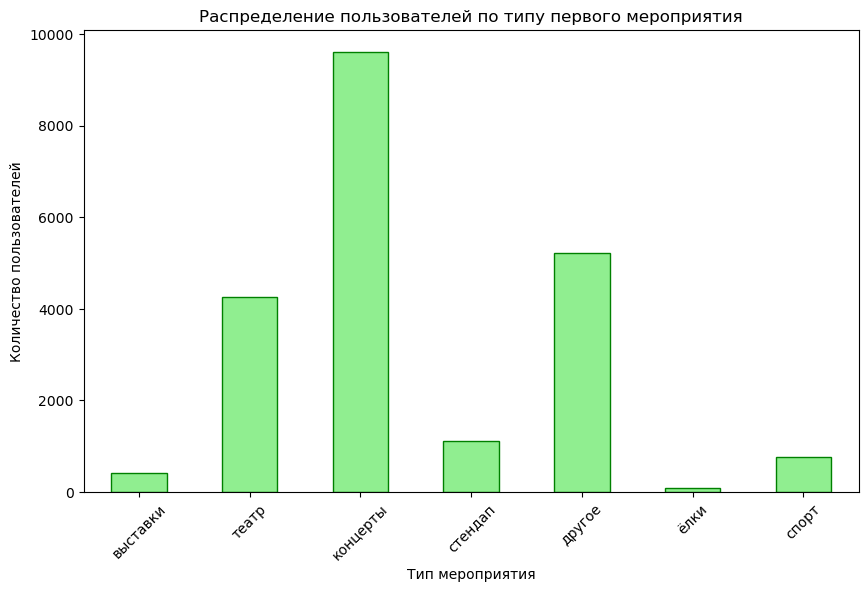

In [109]:
#Визуализируем полученные данные для наглядности
segments_event.plot(
    kind='bar',
    x='first_event_type',      
    y='total_users',           
    rot=45,
    legend=False,
    title='Распределение пользователей по типу первого мероприятия',
    figsize=(10,6),
    edgecolor='green',
    color='lightgreen',
    xlabel='Тип мероприятия',
    ylabel='Количество пользователей'
)

plt.show()

Среди всех категорий первого мероприятия доминируют концерты — `44.7%` пользователей начинали свою активность на платформе именно с них. На втором месте — категория «другое» (`24.3%`), что может указывать на неспецифицированные или смешанные типы событий. Замыкает тройку лидеров театр с долей `19.8%`. Остальные категории (выставки, спорт, стендап и ёлки) в сумме составляют менее `12%`, причём ёлки имеют минимальную долю — всего `0.45%`. Таким образом, основными точками входа для новых пользователей являются концерты и театры, тогда как остальные направления привлекают значительно меньшую аудиторию. Это важно учитывать при настройке рекламных кампаний и персонализации предложений для разных сегментов.

Теперь сгруппируем пользователей по типу устройства, с которого совершена первая покупка:

In [53]:
# Группируем и считаем количество
segments_device = (
    user_profile.groupby('first_device')
    .agg(total_users=('user_id', 'count'), 
         is_two_count=('is_two', 'sum')) #Для следующей задачи
    .reset_index()
    .sort_values('total_users', ascending=False))

# Добавляем столбец с долей 
segments_device['share'] = segments_device['total_users'] / segments_device['total_users'].sum()
segments_device['share_percent'] = segments_device['share'] * 100

segments_device

,first_device,total_users,is_two_count,share,share_percent
1,mobile,17802,10825,0.828655,82.865522
0,desktop,3681,2340,0.171345,17.134478


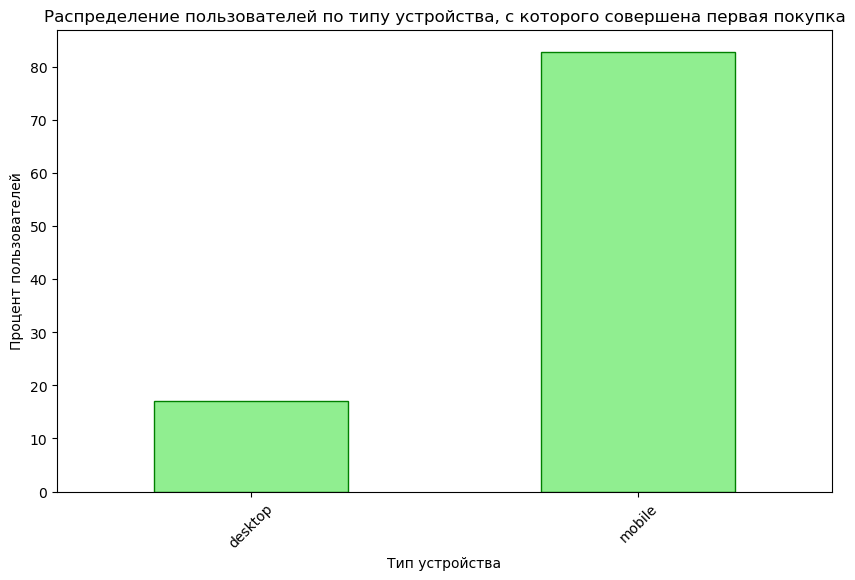

In [108]:
#Визуализируем полученные данные для наглядности
segments_device.plot(
    kind='bar',
    x='first_device',      
    y='share_percent',           
    rot=45,
    legend=False,
    title='Распределение пользователей по типу устройства, с которого совершена первая покупка',
    figsize=(10,6),
    edgecolor='green',
    color='lightgreen',
    xlabel='Тип устройства',
    ylabel='Процент пользователей'
)

plt.show()

Мобильные устройства являются каналом первого контакта пользователей с платформой: на их долю приходится `82.9%` всех первых покупок, тогда как десктопы используют лишь `17.1%`. Такое значительное превосходство говорит о том, что большинство пользователей предпочитают совершать покупки через мобильные приложения или мобильные версии сайта. Это подчёркивает необходимость приоритетной оптимизации мобильного интерфейса, улучшения пользовательского опыта на мобильных устройствах и адаптации рекламных кампаний под мобильную аудиторию. Десктопный сегмент остаётся заметным, но вторичным каналом, который, тем не менее, не следует игнорировать.

Теперь сгруппируем пользователей по региону проведения мероприятия из первого заказа:

In [55]:
# Группируем и считаем количество
segments_region = (
    user_profile.groupby('first_region')
    .agg(total_users=('user_id', 'count'), 
         is_two_count=('is_two', 'sum')) #Для следующей задачи
    .reset_index()
    .sort_values('total_users', ascending=False))

# Добавляем столбец с долей 
segments_region['share'] = segments_region['total_users'] / segments_region['total_users'].sum()
segments_region['share_percent'] = segments_region['share'] * 100

segments_region

,first_region,total_users,is_two_count,share,share_percent
23,Каменевский регион,6973,4317,0.324582,32.458223
60,Североярская область,3783,2423,0.176093,17.609272
77,Широковская область,1234,796,0.057441,5.744077
45,Озернинский край,678,374,0.031560,3.155984
41,Малиновоярский округ,527,294,0.024531,2.453102
...,...,...,...,...,...
17,Залесский край,2,1,0.000093,0.009310
70,Тихогорская область,2,1,0.000093,0.009310
5,Верхозёрский край,1,1,0.000047,0.004655
66,Сосноводолинская область,1,0,0.000047,0.004655


Поскольку регионов много, для визуализации возьмем топ-10 регионов, чтобы не было загромождения:

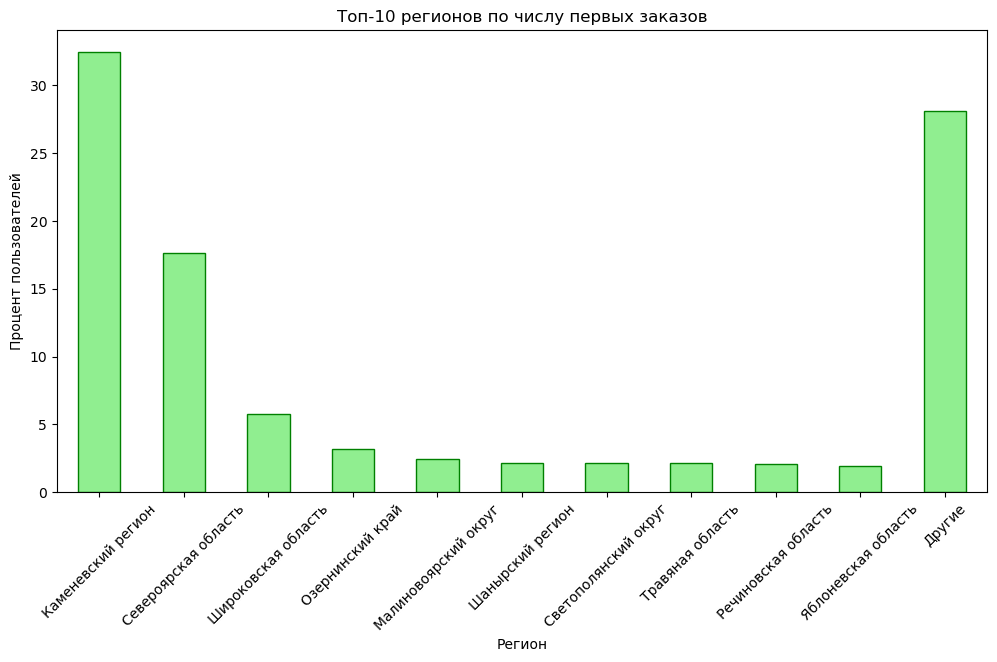

In [107]:
# Топ-10 регионов
top10 = segments_region.head(10).copy()
others = pd.DataFrame({
    'first_region': ['Другие'],
    'total_users': [segments_region['total_users'].iloc[10:].sum()]
})
top10_with_others = pd.concat([top10, others], ignore_index=True)

# Пересчитываем доли для нового датафрейма
top10_with_others['share'] = top10_with_others['total_users'] / top10_with_others['total_users'].sum()
top10_with_others['share_percent'] = top10_with_others['share'] * 100

# Строим график по проценту
top10_with_others.plot(
    kind='bar',
    x='first_region',
    y='share_percent',
    rot=45,
    legend=False,
    title='Топ-10 регионов по числу первых заказов',
    figsize=(12, 6),
    edgecolor='green',
    color='lightgreen',
    xlabel='Регион',
    ylabel='Процент пользователей'
)

plt.show()

Распределение пользователей по регионам первого заказа крайне неравномерно: Каменевский регион и Североярская область в сумме привлекают более половины всех новых пользователей (суммарно `50.1%`), причём на долю Каменевского региона приходится `32.5%` от всей аудитории. Топ-10 регионов (без учёта категории «Другие») включают в себя почти `72%` пользователей, тогда как остальные `71` регион вместе дают лишь `28%`. Основные точки входа приходятся на ограниченное число регионов, что, вероятно, связано с более высокой плотностью населения, развитой инфраструктурой мероприятий или активной рекламной деятельностью в этих локациях. Для маркетинговой стратегии это означает, что усилия по привлечению новых клиентов следует в первую очередь направлять на ключевые регионы, одновременно оценивая потенциал роста в менее охваченных областях. Также стоит изучить причины низкой активности в большинстве регионов, возможно, там недостаточно мероприятий или слабое присутствие платформы.

Теперь сгруппируем пользователей по билетному оператору, продавшему билеты на первый заказ:

In [57]:
# Группируем и считаем количество
segments_service = (
    user_profile.groupby('first_service')
    .agg(total_users=('user_id', 'count'), 
         is_two_count=('is_two', 'sum')) #Для следующей задачи
    .reset_index()
    .sort_values('total_users', ascending=False))

# Добавляем столбец с долей 
segments_service['share'] = segments_service['total_users'] / segments_service['total_users'].sum()
segments_service['share_percent'] = segments_service['share'] * 100

segments_service

,first_service,total_users,is_two_count,share,share_percent
3,Билеты без проблем,4968,2969,0.231253,23.125262
22,Мой билет,2996,1821,0.139459,13.945911
19,Лови билет!,2801,1712,0.130382,13.038216
4,Билеты в руки,2548,1604,0.118605,11.860541
23,Облачко,2196,1347,0.102220,10.222036
7,Весь в билетах,1291,812,0.060094,6.009403
20,Лучшие билеты,1183,727,0.055067,5.506680
24,Прачечная,586,367,0.027277,2.727738
17,Край билетов,460,301,0.021412,2.141228
12,Дом культуры,358,232,0.016664,1.666434


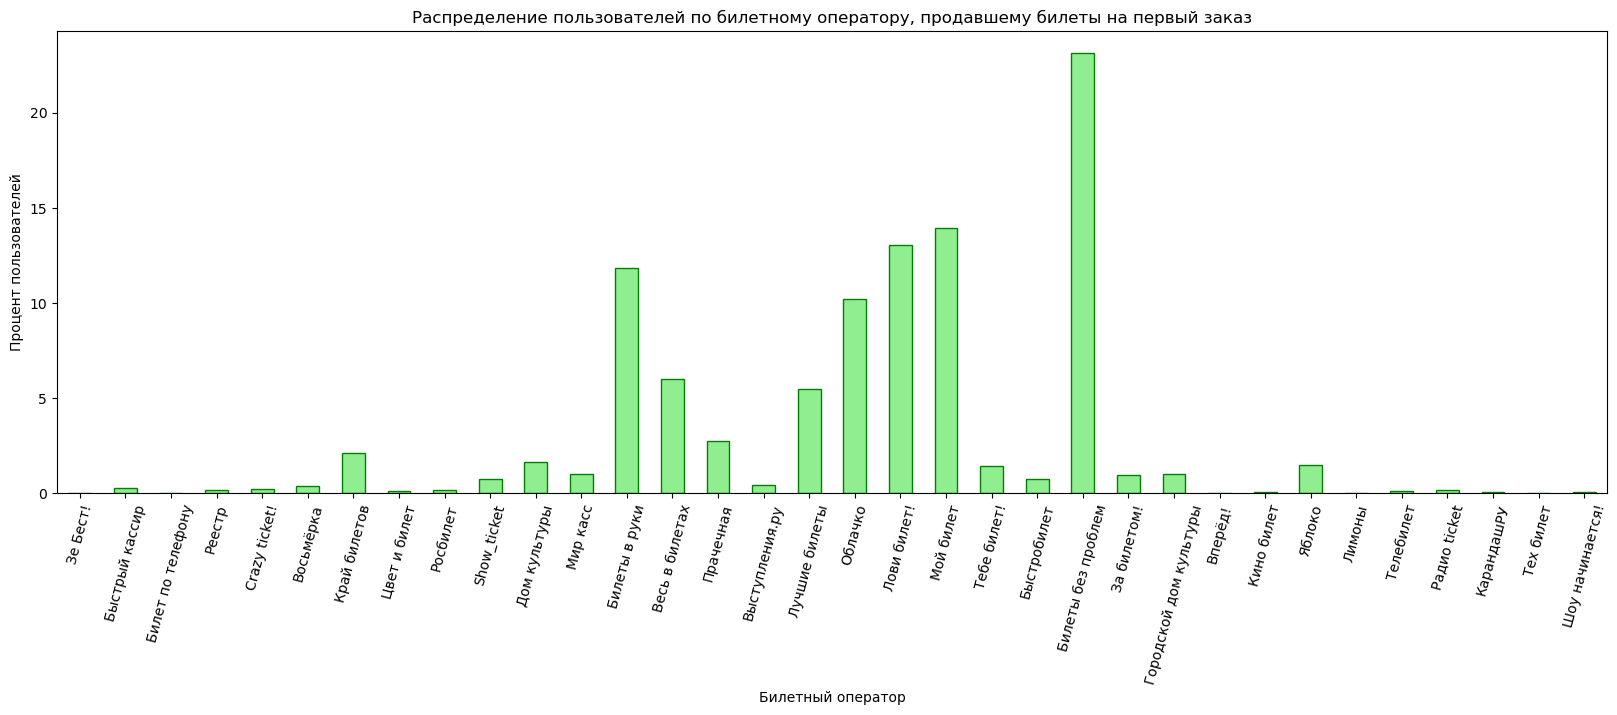

In [106]:
#Визуализируем полученные данные для наглядности
segments_service.plot(
    kind='bar',
    x='first_service',      
    y='share_percent',           
    rot=75,
    legend=False,
    title='Распределение пользователей по билетному оператору, продавшему билеты на первый заказ',
    figsize=(20,6),
    edgecolor='green',
    color='lightgreen',
    xlabel='Билетный оператор',
    ylabel='Процент пользователей'
)

plt.show()

Анализ распределения пользователей по билетному оператору, через которого был совершён первый заказ, показывает несколько явных лидеров. «Билеты без проблем» лидируют с долей `23.1%`, за ними следуют «Мой билет» (`13.9%`), «Лови билет!» (`13.0%`), «Билеты в руки» (`11.9%`) и «Облачко» (`10.2%`). Суммарно топ-5 операторов обслуживают более `72%` всех новых пользователей, что указывает на их доминирующее положение на рынке. Остальные `29` операторов делят оставшиеся `28%` аудитории, причём большинство из них имеют долю менее `1%`. Такая структура говорит о том, что пользователи предпочитают крупных, хорошо известных партнёров, вероятно, благодаря их надёжности, ассортименту или рекламной активности. Для маркетинговой стратегии это означает, что сотрудничество с лидерами рынка критически важно для привлечения потока новых клиентов, однако также может быть перспективным развитие небольших операторов в регионах или для специфических категорий мероприятий, где крупные игроки менее представлены. Также стоит изучить, есть ли корреляция между оператором и последующей лояльностью пользователя, чтобы определить, через каких партнёров приходят наиболее ценные клиенты.

Проведённый анализ распределения пользователей по ключевым признакам первого заказа показывает, что аудитория крайне неравномерно распределена по всем сегментам, с явным доминированием нескольких крупных категорий.

По типу мероприятия безусловным лидером являются концерты, на которые приходится `44.7%` всех первых покупок. Вместе с категорией «другое» (`24.3%`) и театром (`19.8%`) эти три сегмента охватывают почти `90%` новых пользователей. Остальные направления (стендап, спорт, выставки, ёлки) имеют незначительную долю — менее `12%` в сумме.

По типу устройства мобильные телефоны являются абсолютным каналом входа — `82.9%` пользователей совершают первую покупку именно с мобильных устройств. Десктопы занимают второстепенную позицию с долей `17.1%`, что, тем не менее, представляет заметный сегмент.

По региону концентрация ещё более выражена: Каменевский регион и Североярская область в сумме привлекают `50.1%` всех новых пользователей, причём на долю первого приходится `32.5%`. Топ-10 регионов аккумулируют почти `72%` аудитории, тогда как остальные `71` регион дают лишь `28%`. Это указывает на сильную географическую привязку спроса.

По билетному оператору топ-5 компаний («Билеты без проблем», «Мой билет», «Лови билет!», «Билеты в руки», «Облачко») обслуживают более `72%` новых клиентов. При этом лидер — «Билеты без проблем» — имеет долю `23.1%`, что почти вдвое превышает долю второго оператора (`13.9%`).

Таким образом, распределение пользователей по всем рассмотренным признакам крайне неравномерно: везде есть ярко выраженные точки входа, которые привлекают основную массу новых клиентов. Это типично для рынка с несколькими доминирующими игроками и направлениями. Для стратегии привлечения пользователей это означает, что усилия следует концентрировать на наиболее массовых сегментах, одновременно оценивая потенциал остальных направлений. Также важно изучить, сохраняется ли такая же неравномерность в поведении лояльных пользователей (с повторными заказами), чтобы понять, какие сегменты дают не только поток новых клиентов, но и их долгосрочное удержание.

---

**Задача 4.1.2.** Проанализируем возвраты пользователей:

- Для каждого сегмента вычислим долю пользователей, совершивших два и более заказа.
- Визуализируем результат подходящим графиком. Если сегментов слишком много, то поместим на график только 10 сегментов с наибольшим количеством пользователей.
- Ответим на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учтем размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


Вычислим долю пользователей, совершивших два и более заказа для сегментов с первым мероприятием:

In [59]:
#Создаем новый столбец с долей пользователей
segments_event['is_two_ratio'] = segments_event['is_two_count']/segments_event['total_users']

#Сортируем для удобства
segments_event = segments_event.sort_values('is_two_ratio', ascending = False)

segments_event

,first_event_type,total_users,is_two_count,share,share_percent,is_two_ratio
0,выставки,415,267,0.019318,1.931760,0.643373
5,театр,4259,2704,0.198250,19.824978,0.634891
2,концерты,9607,5935,0.447191,44.719080,0.617779
4,стендап,1117,680,0.051995,5.199460,0.608774
1,другое,5223,3104,0.243122,24.312247,0.594294
6,ёлки,97,55,0.004515,0.451520,0.567010
3,спорт,765,420,0.035610,3.560955,0.549020


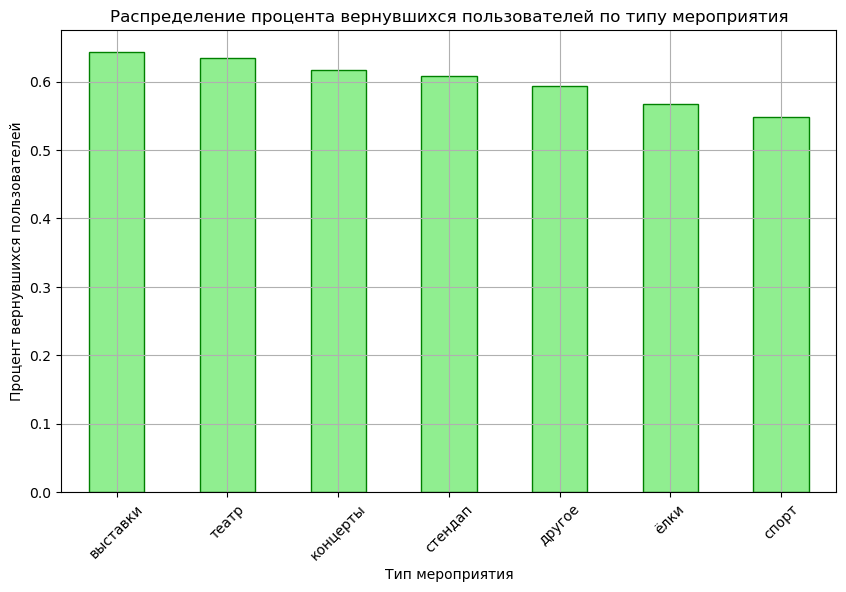

In [105]:
#Визуализируем полученные данные для наглядности
segments_event.plot(
    kind='bar',
    x='first_event_type',      
    y='is_two_ratio',           
    rot=45,
    legend=False,
    title='Распределение процента вернувшихся пользователей по типу мероприятия',
    figsize=(10,6),
    edgecolor='green',
    color='lightgreen',
    xlabel='Тип мероприятия',
    ylabel='Процент вернувшихся пользователей',
    grid = True
)

plt.show()

По результатам расчёта доли вернувшихся пользователей (сделавших два и более заказа) в разрезе типа первого мероприятия, все сегменты демонстрируют высокие показатели возврата, превышающие средний уровень по выборке (`61.7%`). Наивысшая доля наблюдается у категории «выставки» (`64.3%`), но следует учитывать небольшой объём этого сегмента (`415` пользователей), что может давать нестабильную оценку. Среди массовых сегментов театр (`63.5%`) и концерты (`61.8%`) показывают результаты, близкие к среднему, и именно они обеспечивают основной вклад в повторные покупки. Минимальная доля зафиксирована в категории «спорт» (`54.9%`), что всё равно является высоким значением. Таким образом, можно заключить, что все рассмотренные категории мероприятий являются успешными точками входа, обеспечивающими устойчивый возврат пользователей. Особенно стоит выделить театр и выставки, которые не только привлекают аудиторию, но и стимулируют её к повторным заказам, что делает их приоритетными для рекламных кампаний, направленных на удержание клиентов. 

Вычислим долю пользователей, совершивших два и более заказа для сегментов с первым устройством:

In [61]:
#Создаем новый столбец с долей пользователей
segments_device['is_two_ratio'] = segments_device['is_two_count']/segments_device['total_users']

#Сортируем для удобства
segments_device = segments_device.sort_values('is_two_ratio', ascending = False)

segments_device

,first_device,total_users,is_two_count,share,share_percent,is_two_ratio
0,desktop,3681,2340,0.171345,17.134478,0.635697
1,mobile,17802,10825,0.828655,82.865522,0.608078


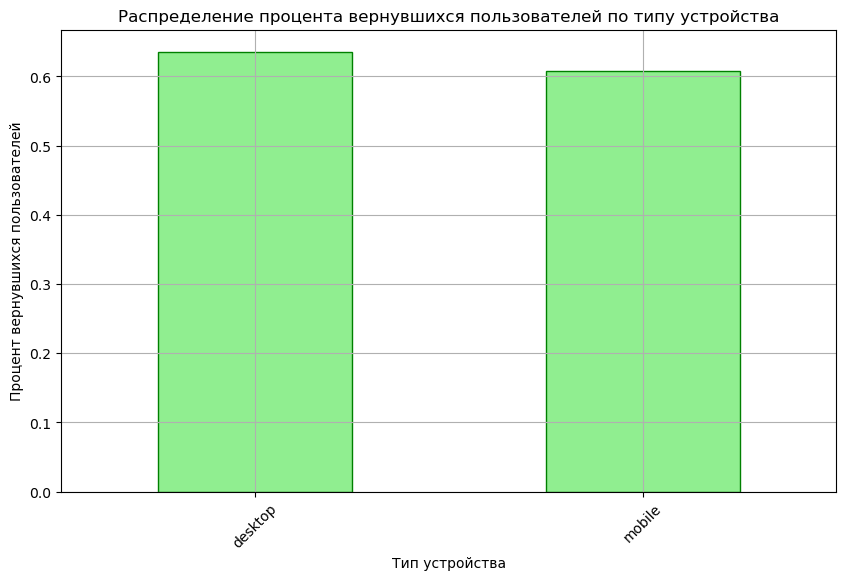

In [104]:
#Визуализируем полученные данные для наглядности
segments_device.plot(
    kind='bar',
    x='first_device',      
    y='is_two_ratio',           
    rot=45,
    legend=False,
    title='Распределение процента вернувшихся пользователей по типу устройства',
    figsize=(10,6),
    edgecolor='green',
    color='lightgreen',
    xlabel='Тип устройства',
    ylabel='Процент вернувшихся пользователей',
    grid = True
)

plt.show()

По результатам расчёта доли вернувшихся пользователей в разрезе типа устройства первого заказа, оба сегмента демонстрируют близкие к среднему (`61.7%`) показатели. Для десктопов доля возврата составляет `63.6%`, что немного выше среднего, для мобильных устройств — `60.8%`, что чуть ниже среднего. Однако разница невелика (менее `3` процентов) и может быть статистически незначимой. С учётом того, что мобильный сегмент составляет `82.9%` всех пользователей, его вклад в общее число повторных заказов является определяющим. Оба типа устройств можно считать успешными точками входа, при этом десктопная аудитория демонстрирует незначительно более высокую лояльность. В целом никаких выраженных аномалий не обнаружено.

Вычислим долю пользователей, совершивших два и более заказа для сегментов с первым регионом проведения мероприятия:

In [63]:
#Создаем новый столбец с долей пользователей
segments_region['is_two_ratio'] = segments_region['is_two_count']/segments_region['total_users']

segments_region

,first_region,total_users,is_two_count,share,share_percent,is_two_ratio
23,Каменевский регион,6973,4317,0.324582,32.458223,0.619102
60,Североярская область,3783,2423,0.176093,17.609272,0.640497
77,Широковская область,1234,796,0.057441,5.744077,0.645057
45,Озернинский край,678,374,0.031560,3.155984,0.551622
41,Малиновоярский округ,527,294,0.024531,2.453102,0.557875
...,...,...,...,...,...,...
17,Залесский край,2,1,0.000093,0.009310,0.500000
70,Тихогорская область,2,1,0.000093,0.009310,0.500000
5,Верхозёрский край,1,1,0.000047,0.004655,1.000000
66,Сосноводолинская область,1,0,0.000047,0.004655,0.000000


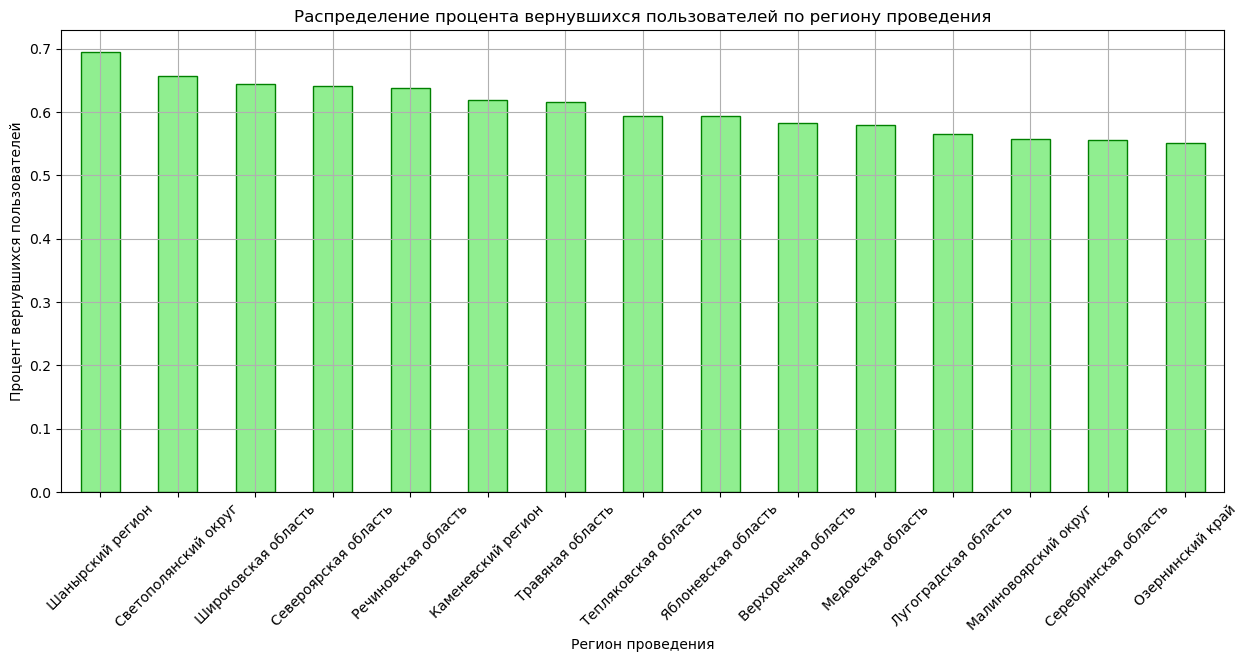

In [103]:
#Визуализируем полученные данные для наглядности, берем только регионы с большим количеством пользователей
segments_region.head(15).sort_values('is_two_ratio', ascending = False).plot(
    kind='bar',
    x='first_region',      
    y='is_two_ratio',           
    rot=45,
    legend=False,
    title='Распределение процента вернувшихся пользователей по региону проведения',
    figsize=(15,6),
    edgecolor='green',
    color='lightgreen',
    xlabel='Регион проведения',
    ylabel='Процент вернувшихся пользователей',
    grid = True
)

plt.show()

In [65]:
segments_region.head(15).sort_values('is_two_ratio', ascending = False)

,first_region,total_users,is_two_count,share,share_percent,is_two_ratio
76,Шанырский регион,465,323,0.021645,2.164502,0.694624
57,Светополянский округ,461,303,0.021459,2.145883,0.657267
77,Широковская область,1234,796,0.057441,5.744077,0.645057
60,Североярская область,3783,2423,0.176093,17.609272,0.640497
52,Речиновская область,445,284,0.020714,2.071405,0.638202
23,Каменевский регион,6973,4317,0.324582,32.458223,0.619102
74,Травяная область,461,284,0.021459,2.145883,0.616052
69,Тепляковская область,323,192,0.015035,1.503514,0.594427
78,Яблоневская область,411,244,0.019131,1.913141,0.593674
6,Верхоречная область,381,222,0.017735,1.773495,0.582677


Расчёт доли пользователей, совершивших два и более заказа, по каждому региону показал крайне высокую вариативность: показатели варьируются от `0%` до `100%`. Однако это напрямую связано с размером сегментов: в регионах с небольшим числом пользователей доля возврата может сильно колебаться из-за случайных отклонений и не является статистически надёжной (например, Верхозёрский край с `1` пользователем показывает `100%` возврат, а Яснопольский округ с `1` пользователем — `0%`). Такие значения не следует использовать для принятия решений.

Для содержательного анализа имеет смысл рассматривать только регионы с достаточным числом первых заказов (в нашем случае топ-15 по количеству пользователей). Из ранее выделенных крупных регионов лидерами по доле возврата являются: Шанырский регион(`~69.4%`), Светополянский округ (`~65.7%`), Широковская область (`~64.5%`).

Они показывают результаты, близкие к среднему по выборке (`61.7%`). Ни один из крупных регионов не демонстрирует значительного превышения средней доли возврата. Это позволяет предположить, что географический фактор не является ключевым признаком для повторных покупок — крупные регионы ведут себя примерно одинаково с точки зрения удержания аудитории. Регионы с аномально высокими долями (например, Озернопольская область с `89.7%`) имеют слишком малую выборку, чтобы делать выводы, и их показатели следует интерпретировать с осторожностью.

Таким образом, в разрезе регионов ярко выраженных «успешных точек входа» не обнаружено — все крупные регионы дают сопоставимый уровень возврата, а экстремальные значения объясняются малым размером сегментов. Для маркетинговых решений стоит ориентироваться на стабильные показатели крупных регионов, а в малых сегментах проводить дополнительные исследования для проверки достоверности.



Вычислим долю пользователей, совершивших два и более заказа для сегментов с первым билетным оператором:

In [66]:
#Создаем новый столбец с долей пользователей
segments_service['is_two_ratio'] = segments_service['is_two_count']/segments_service['total_users']

#Сортируем для удобства
segments_service = segments_service.sort_values('is_two_ratio', ascending = False)

segments_service

,first_service,total_users,is_two_count,share,share_percent,is_two_ratio
14,Зе Бест!,1,1,0.000047,0.004655,1.000000
6,Быстрый кассир,61,52,0.002839,0.283945,0.852459
2,Билет по телефону,6,5,0.000279,0.027929,0.833333
26,Реестр,33,27,0.001536,0.153610,0.818182
0,Crazy ticket!,46,32,0.002141,0.214123,0.695652
8,Восьмёрка,86,59,0.004003,0.400317,0.686047
17,Край билетов,460,301,0.021412,2.141228,0.654348
31,Цвет и билет,23,15,0.001071,0.107061,0.652174
27,Росбилет,40,26,0.001862,0.186194,0.650000
1,Show_ticket,157,102,0.007308,0.730810,0.649682


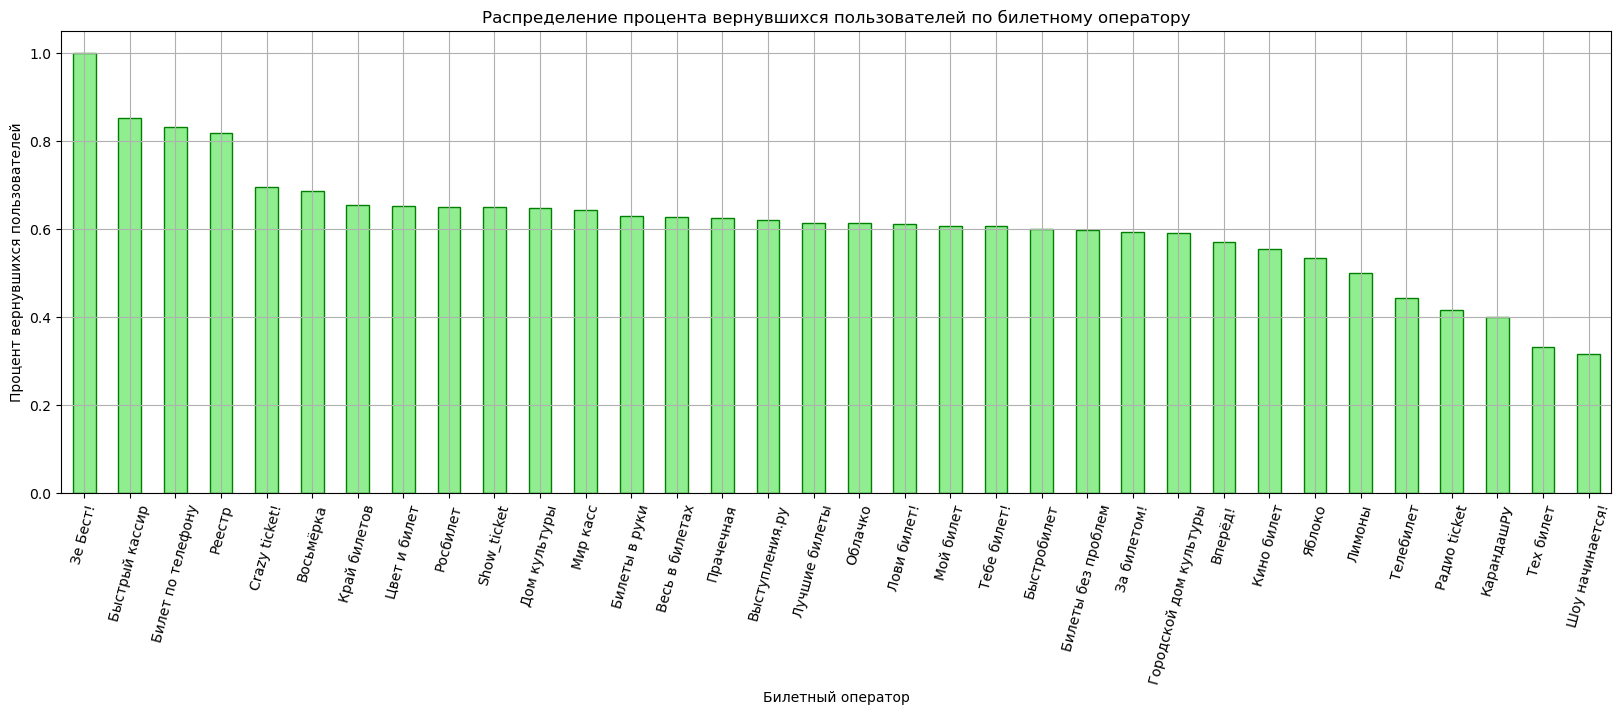

In [102]:
#Визуализируем полученные данные для наглядности
segments_service.plot(
    kind='bar',
    x='first_service',      
    y='is_two_ratio',           
    rot=75,
    legend=False,
    title='Распределение процента вернувшихся пользователей по билетному оператору',
    figsize=(20,6),
    edgecolor='green',
    color='lightgreen',
    xlabel='Билетный оператор',
    ylabel='Процент вернувшихся пользователей',
    grid = True
)
plt.show()

По результатам расчёта доли вернувшихся пользователей в разрезе билетного оператора, через которого был совершён первый заказ, наблюдается высокий разброс значений — от `100%` (Зе Бест!, `1` пользователь) до `31.6%` (Шоу начинается!, `19` пользователей). Однако, как и в случае с регионами, экстремальные показатели приходятся на сегменты с крайне малым числом пользователей (менее `100` человек), где статистическая погрешность велика, и доверять таким цифрам нельзя. Например, «Быстрый кассир» с `61` пользователем показывает `85.2%` возврата, что может быть случайностью.

Среди крупных операторов (с числом пользователей более `500`) ситуация более стабильна:

«Край билетов» (`460` пользователей) — `65.4%` возврата, что немного выше среднего (`61.7%`), «Билеты в руки» (`2548`) — `63.0%`, «Весь в билетах» (`1291`) — `62.9%`, «Прачечная» (`586`) — `62.6%`, «Лучшие билеты» (`1183`) — `61.5%`.

Лидер по объёму «Билеты без проблем» (`4968`) — `59.8%`, что немного ниже среднего.

Таким образом, большинство крупных операторов демонстрируют показатели возврата в диапазоне `60–65%`, близкие к среднему по выборке. Ярко выраженных «успешных точек входа» среди операторов не обнаружено – все основные игроки дают сопоставимый уровень лояльности. Операторы с аномально высокими долями (Зе Бест!, Быстрый кассир) имеют слишком малую выборку, чтобы делать обоснованные выводы. Для маркетинговой стратегии это означает, что выбор билетного партнёра не является критическим фактором удержания – пользователи, пришедшие через любого из крупных операторов, с равной вероятностью вернутся. В целом же все операторы могут считаться равноценными с точки зрения привлечения лояльной аудитории.

Проведённый анализ возвратов пользователей по сегментам первого заказа показывает, что доля повторных покупок близка к среднему уровню (`61.7%`) во всех основных категориях и не имеет ярко выраженных «точек входа» с аномально высокой лояльностью. По типу мероприятия лидируют выставки (`64,3%`) и театр (`63,5%`), а спорт показывает минимальное значение (`54,9%`), однако эти различия невелики. По типу устройства десктопные усттройства незначительно опережают мобильные (`63,6%` против `60,8%`), но поскольку мобильный сегмент составляет `83%` аудитории, его вклад в общее число повторных заказов определяющий. В разрезе регионов и билетных операторов крупные сегменты также дают показатели в диапазоне `60–65%`, тогда как экстремальные значения (`0%` или `100%`) наблюдаются исключительно в группах с числом пользователей менее `100` и не могут считаться статистически надёжными. Таким образом, ни один из рассмотренных признаков не выступает как признак удержания, а значит, усилия по повышению лояльности следует направлять на общее качество сервиса и впечатления от первого заказа, а не на отдельные сегменты. Сегменты с малой выборкой требуют осторожной интерпретации и дополнительного исследования перед принятием решений.

---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверим продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

**Проверка продуктовых гипотез:**

**Гипотеза 1** о том, что пользователи, начавшие с покупки билетов на спортивные мероприятия, возвращаются чаще, чем пользователи с первого заказа на концерты, не подтверждается. Фактические данные показывают обратную картину: доля повторных заказов среди посетителей концертов составляет `61,8%`, тогда как среди спорта — лишь `54,9%`, что является самым низким показателем среди всех категорий мероприятий. Таким образом, спортивные события не только не стимулируют возврат, но и демонстрируют наименьшую лояльность аудитории. Это может быть связано с сезонностью, разовой природой многих спортивных событий или спецификой аудитории, которая реже совершает повторные покупки на платформе.

**Гипотеза 2** о том, что в регионах с наибольшей пользовательской активностью выше доля повторных заказов, также не подтверждается. Сравнение крупнейших регионов показывает, что их показатели возврата варьируются в широком диапазоне: от `55,2%` (Озернинский край) до `69,5%` (Шанырский регион) без явной связи с размером аудитории. Например, самый многочисленный Каменевский регион (`6973` пользователя) имеет долю возврата `61,9%`, что близко к среднему, тогда как значительно меньший по объёму Шанырский регион (`465` пользователей) показывает наивысший результат `69,5%`. Следовательно, масштаб региона не определяет лояльность пользователей — вероятно, решающую роль играют другие факторы, такие как разнообразие мероприятий, ценовая политика или предпочтения местной аудитории.

Таким образом, обе гипотезы отвергаются. Для повышения удержания пользователей стоит сосредоточиться на универсальных показателях лояльности (качество сервиса, удобство покупки, соответствющие интересам рекомендации) и проводить более глубокий анализ в регионах с неожиданно высокими или низкими показателями для выявления локальных особенностей.

---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучим количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследим связь между средней выручкой сервиса с заказа и повторными заказами.

- Построим сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответим на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

    
**Рекомендация:**

1. Используем одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Зададим параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


Построим сравнительные гистограммы распределения средней выручки с билета (avg_revenue_rub):

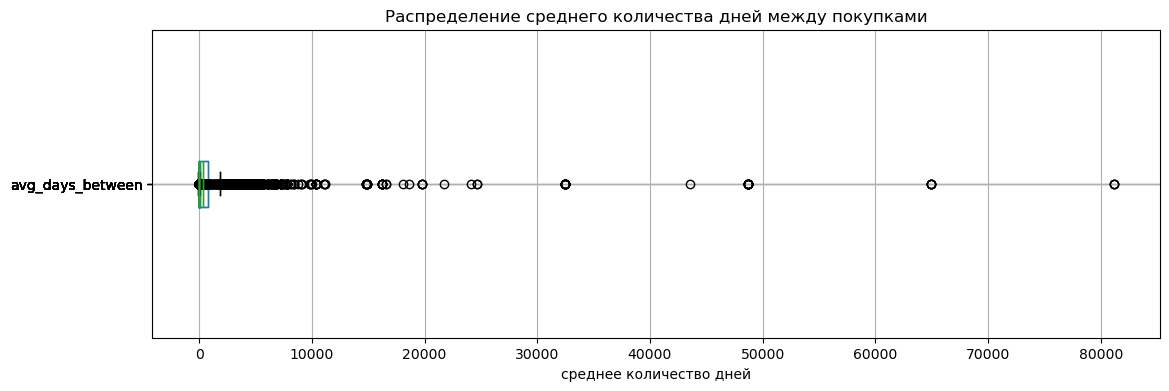

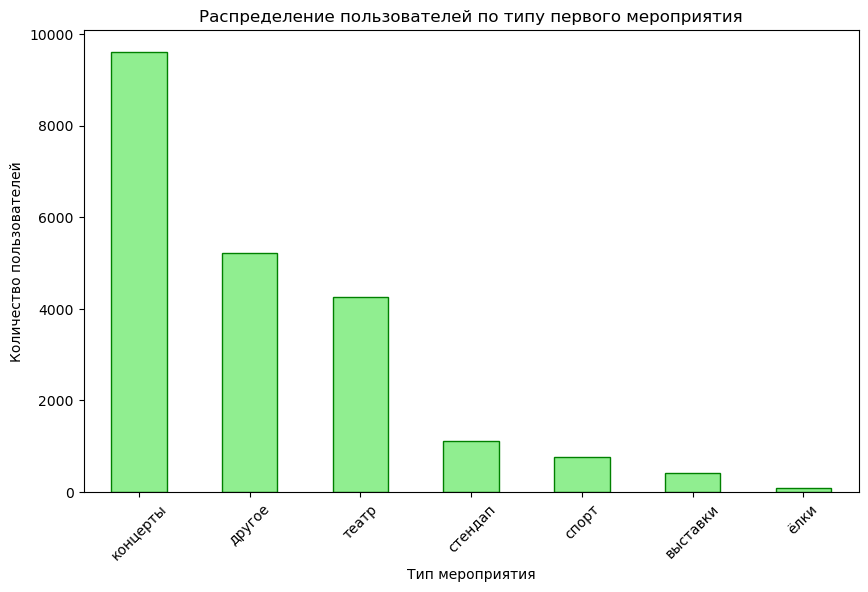

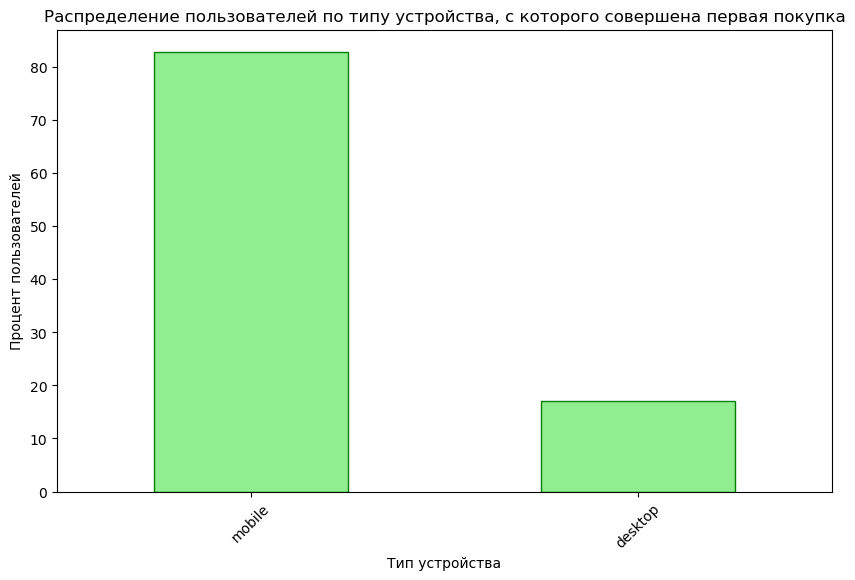

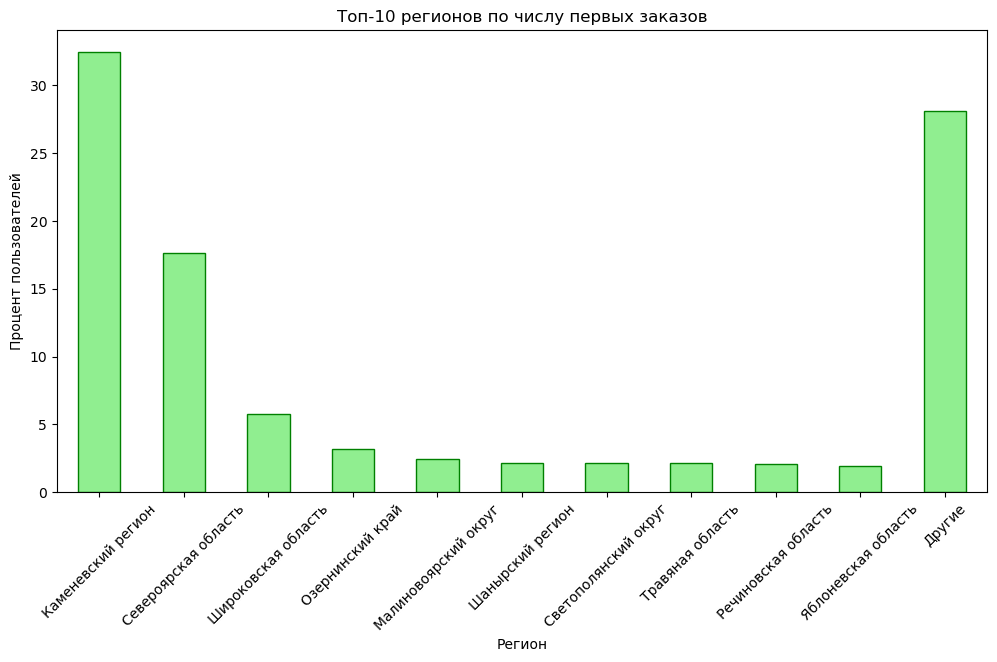

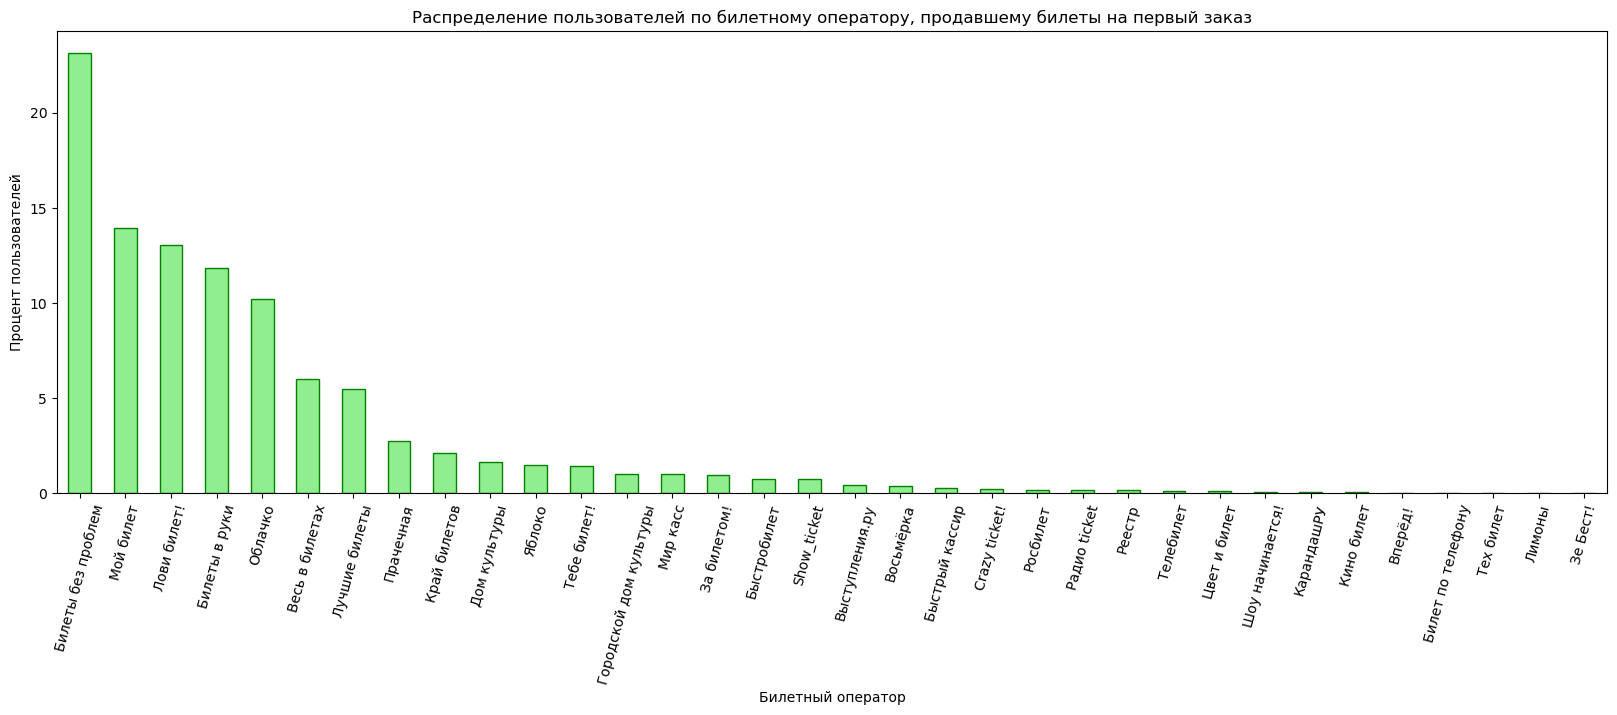

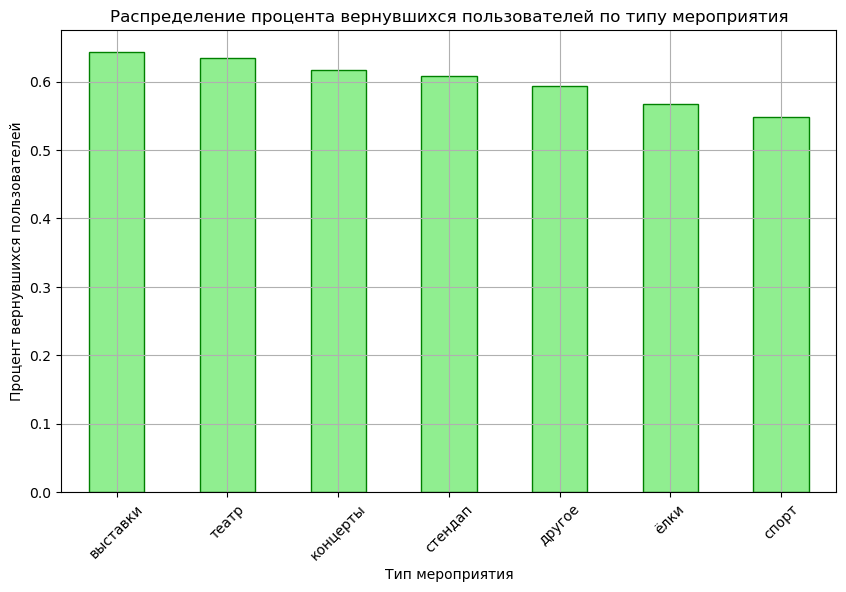

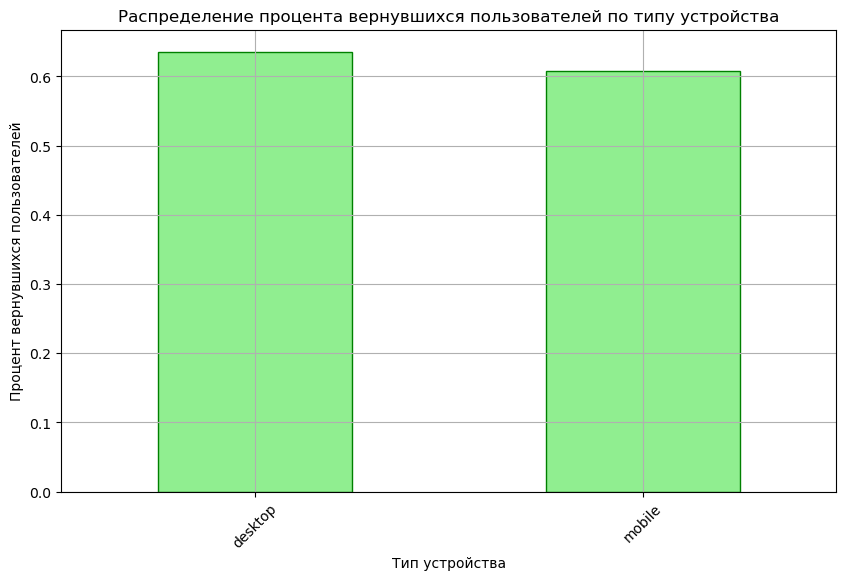

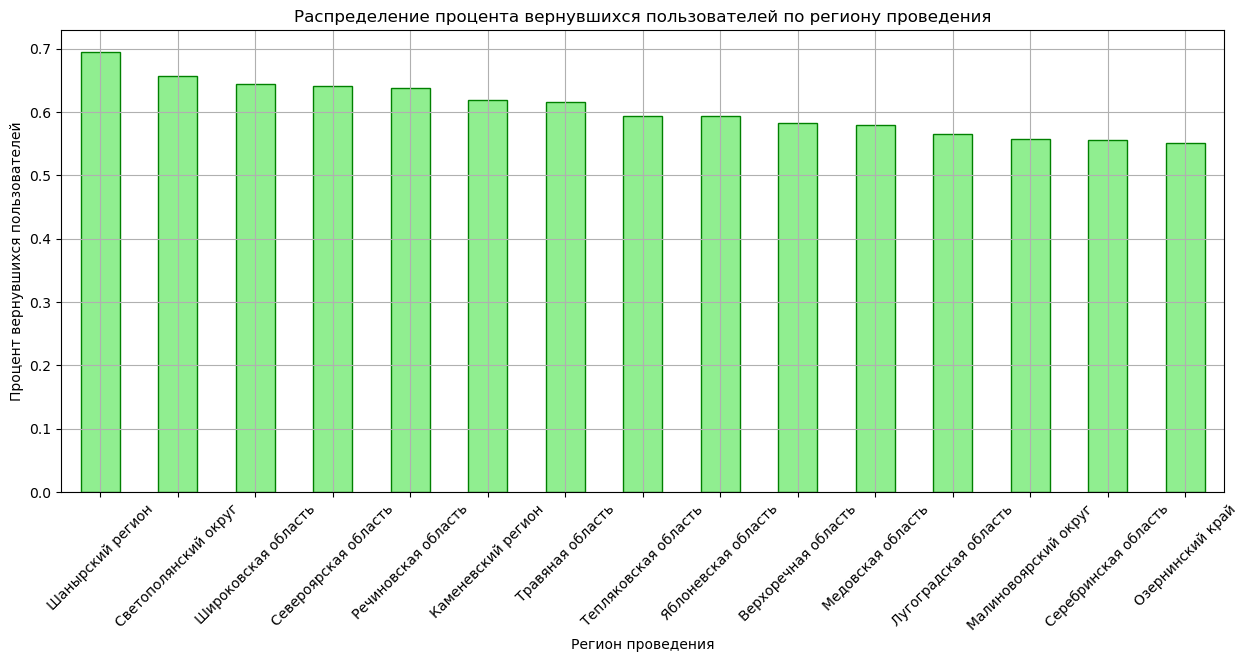

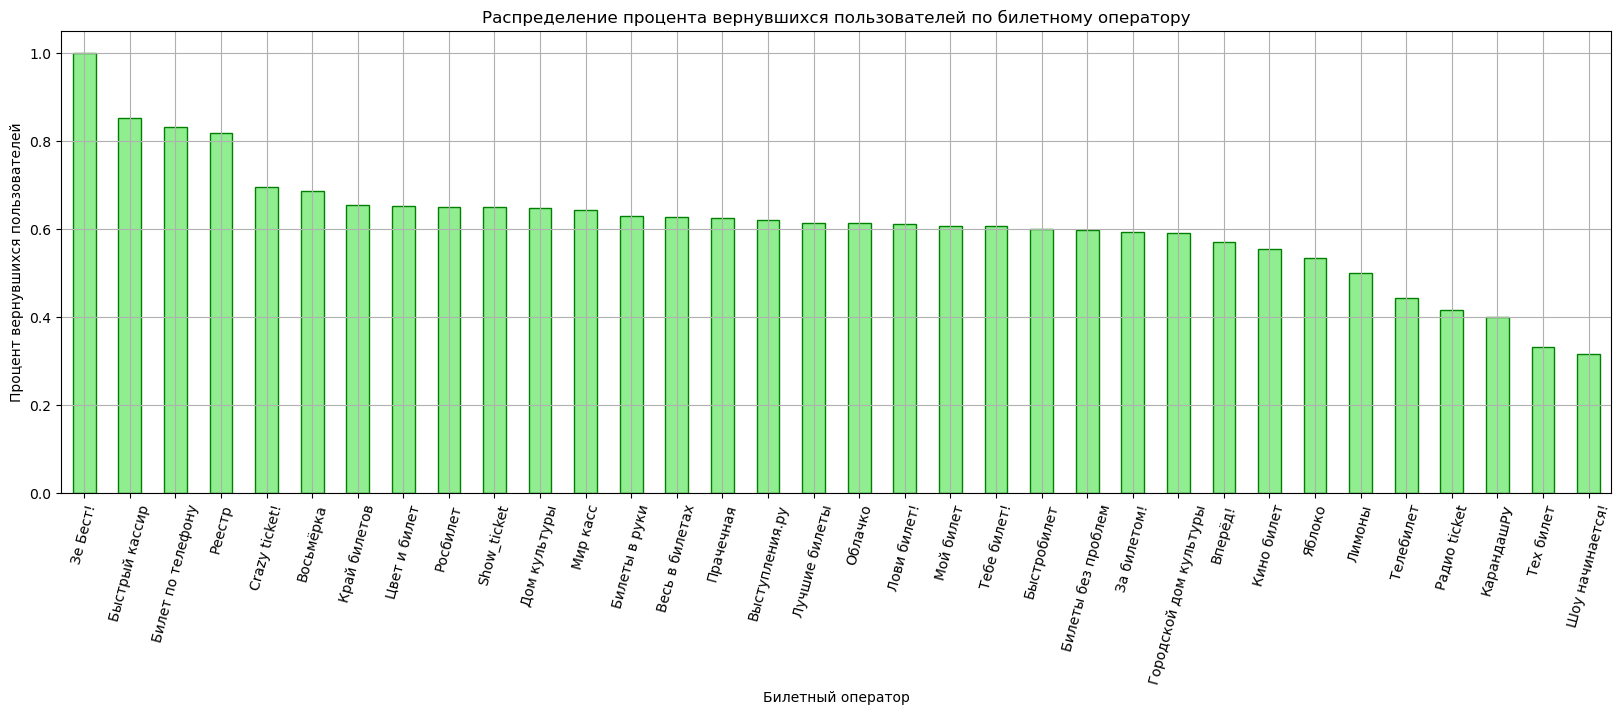

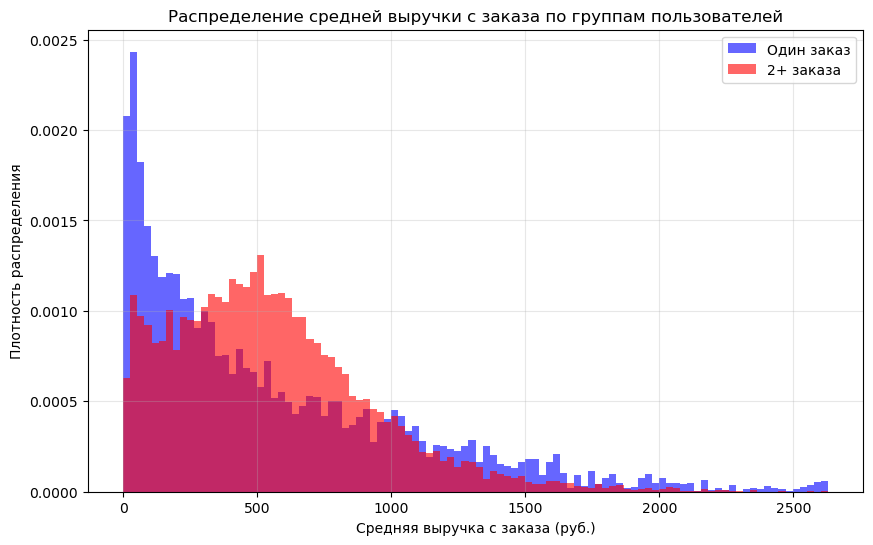

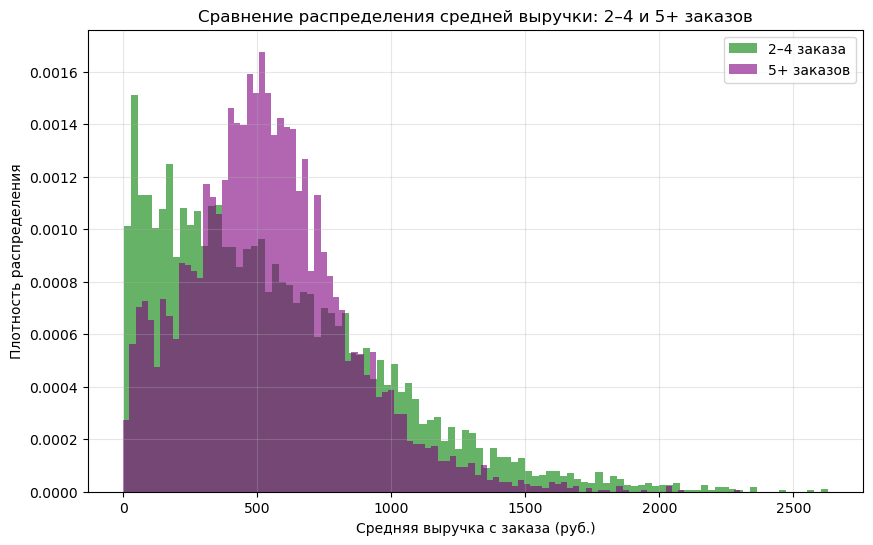

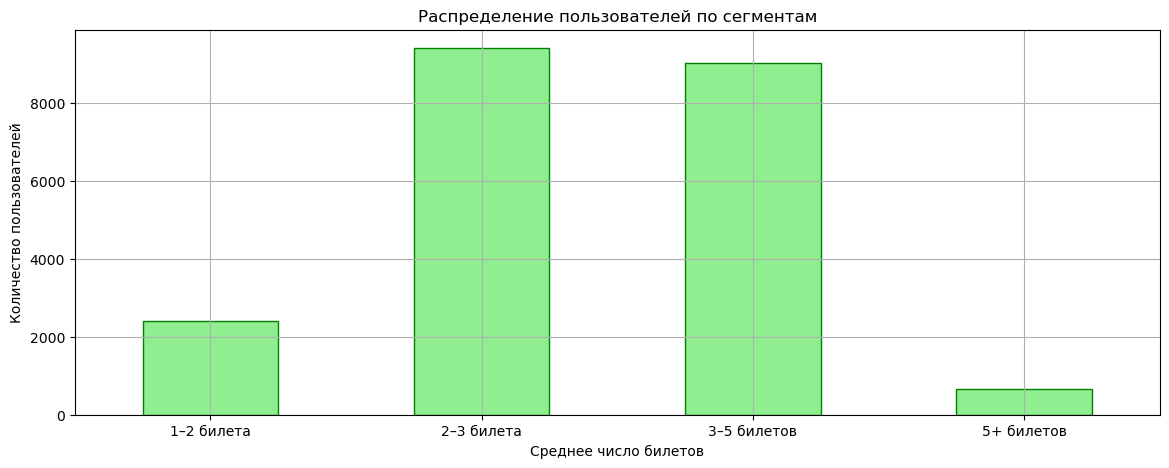

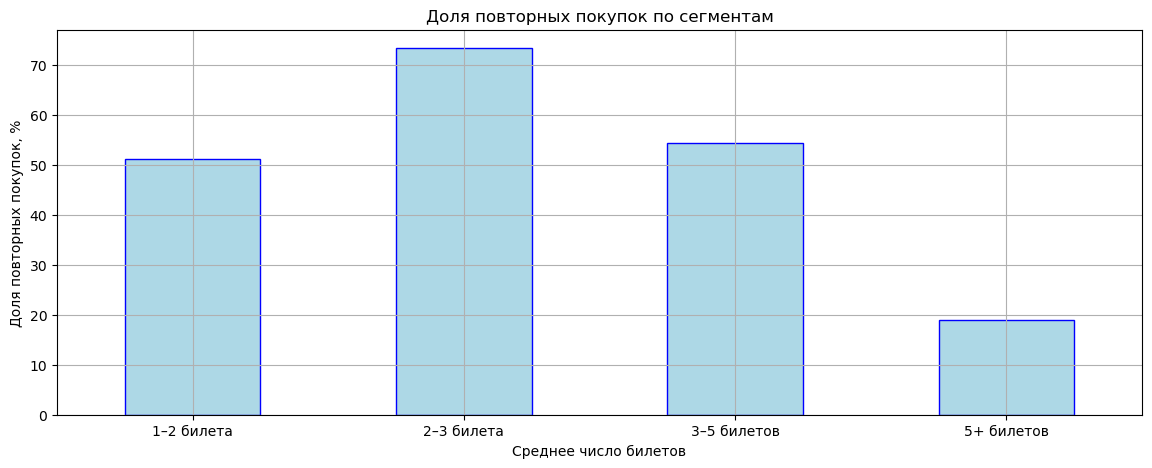

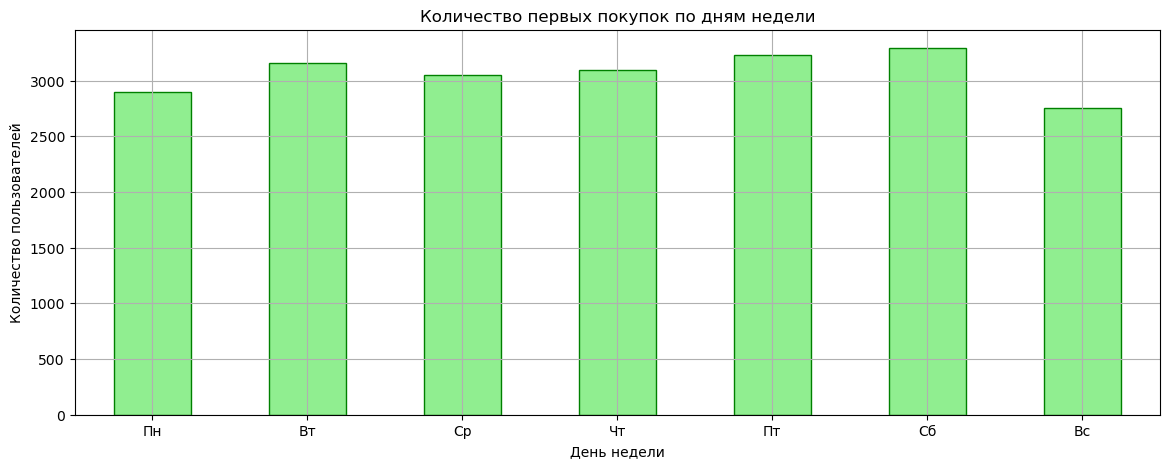

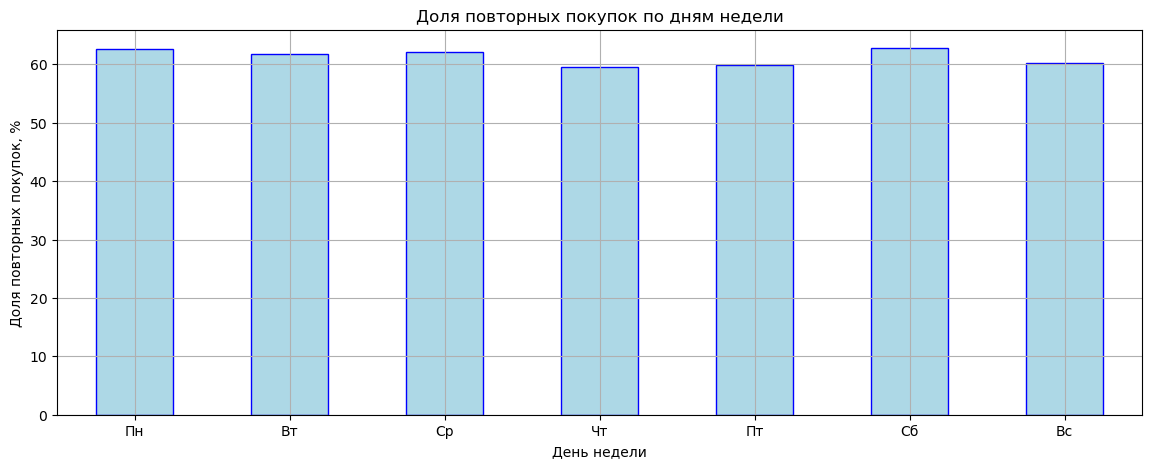

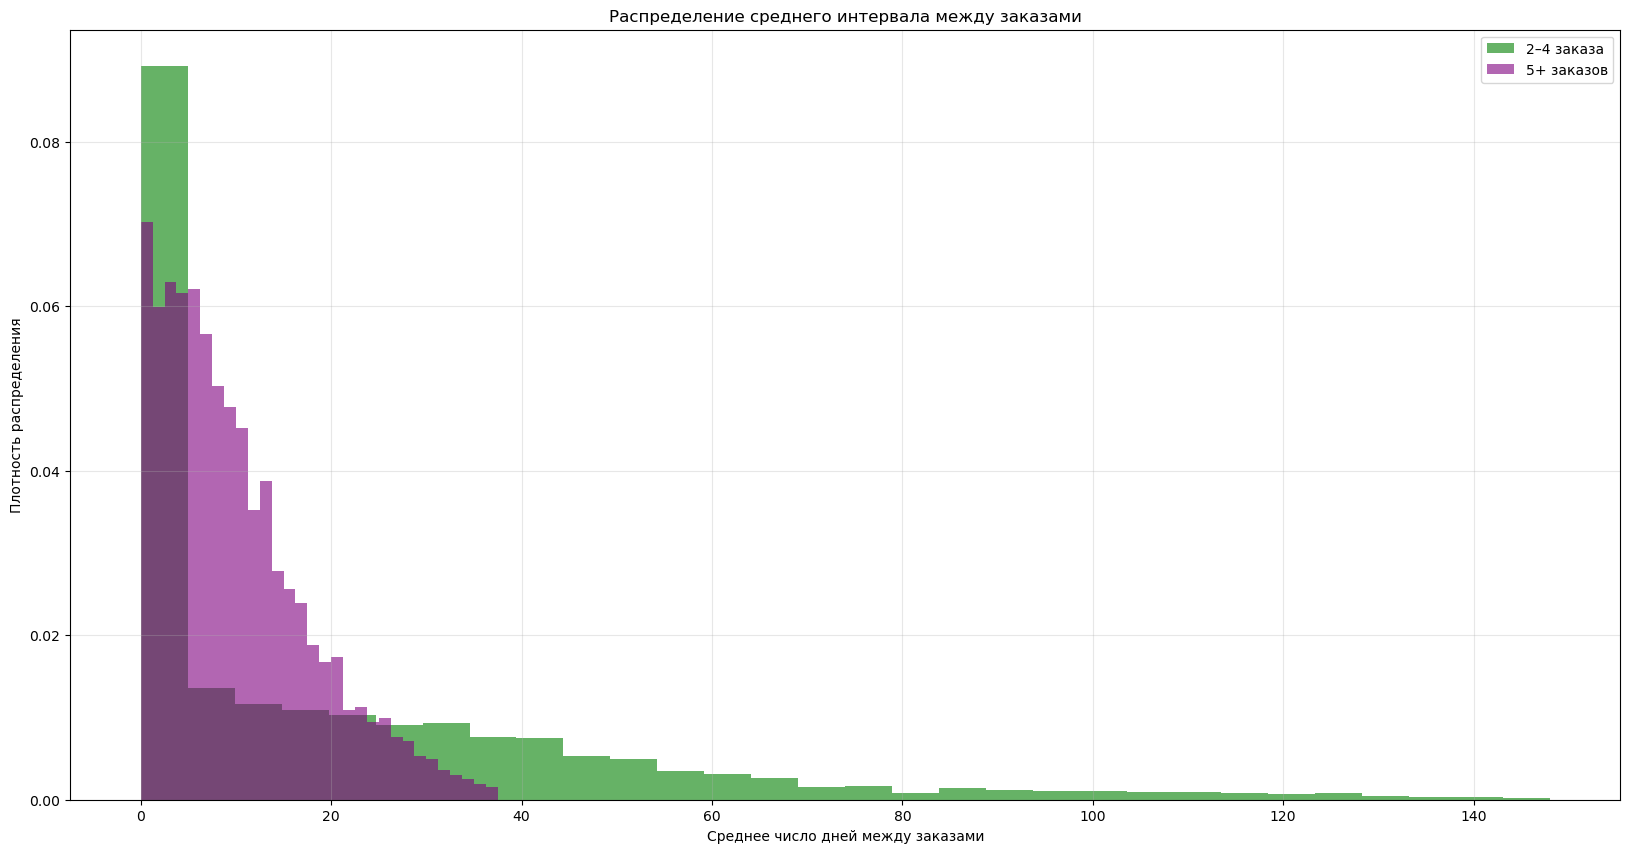

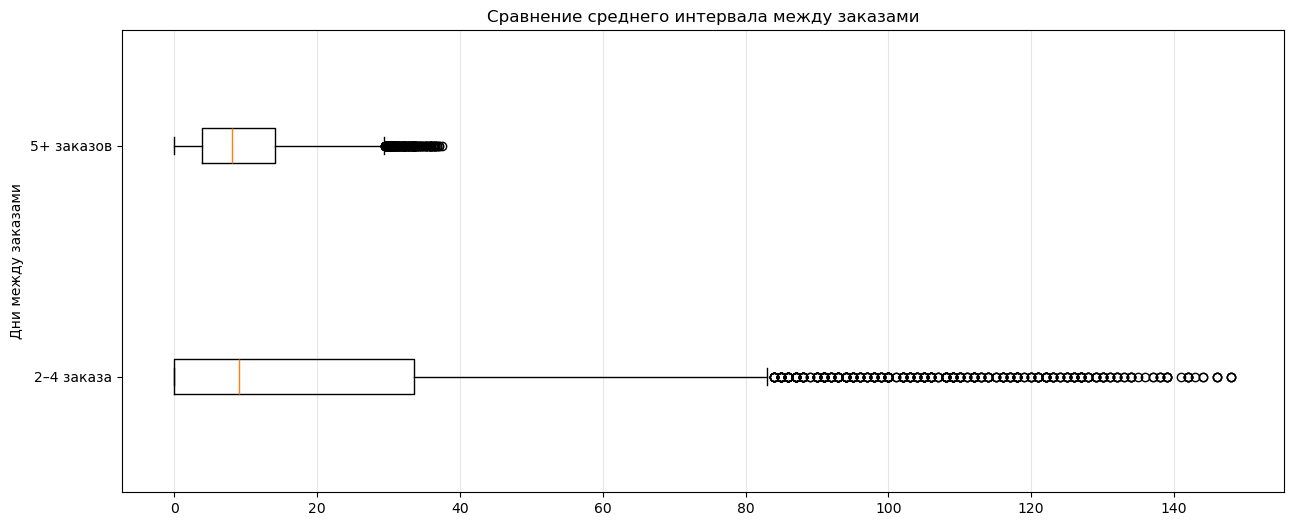

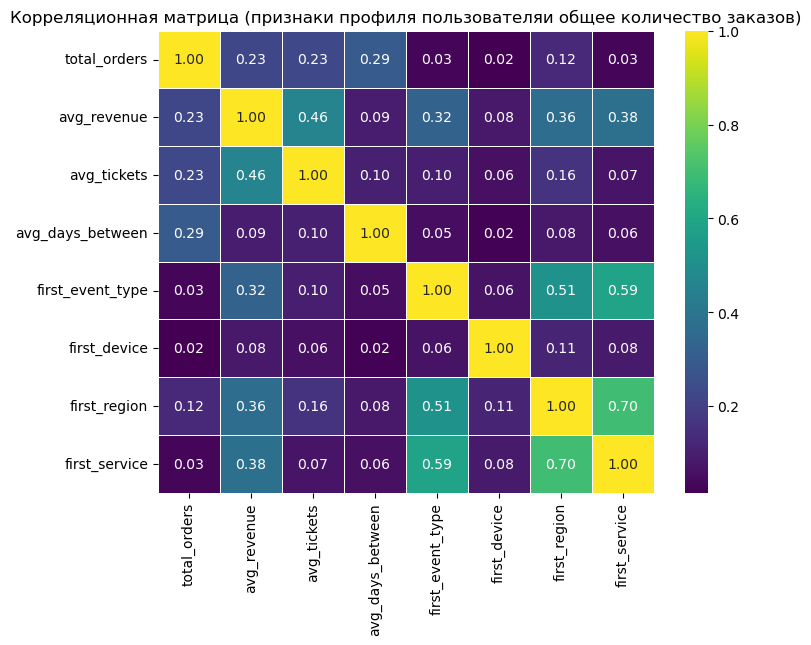

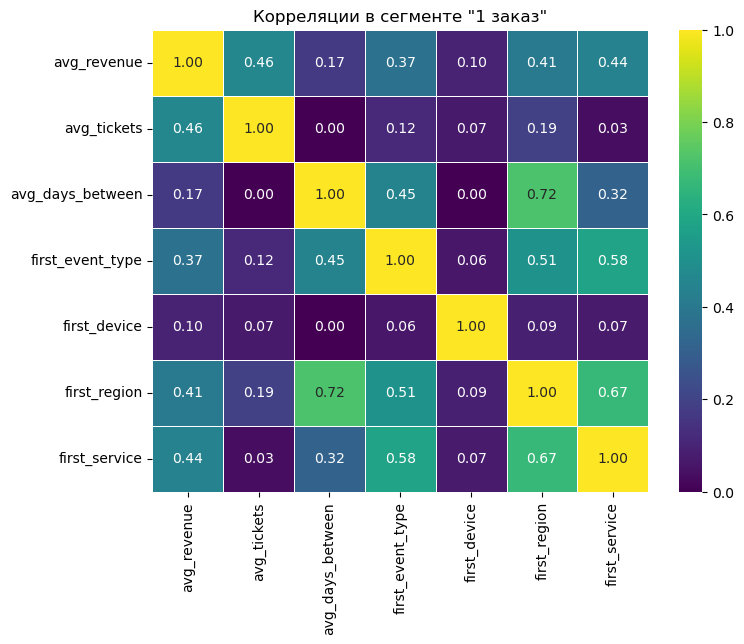

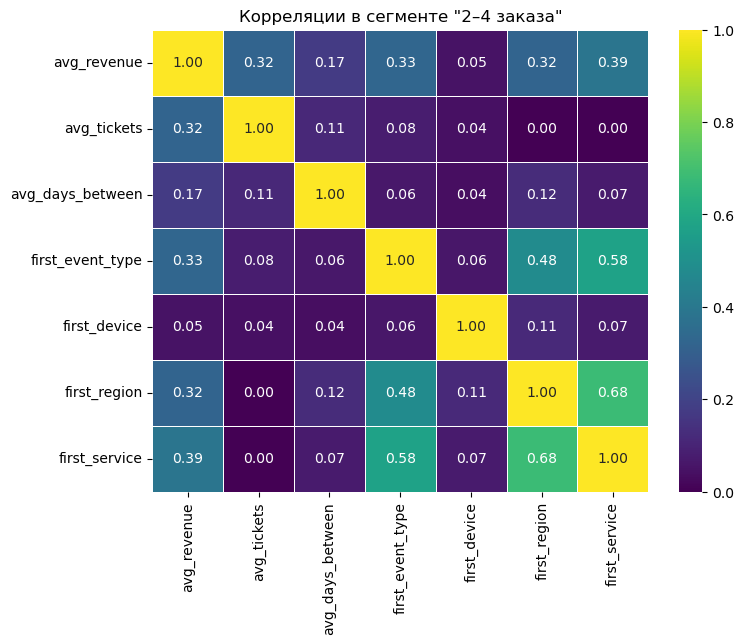

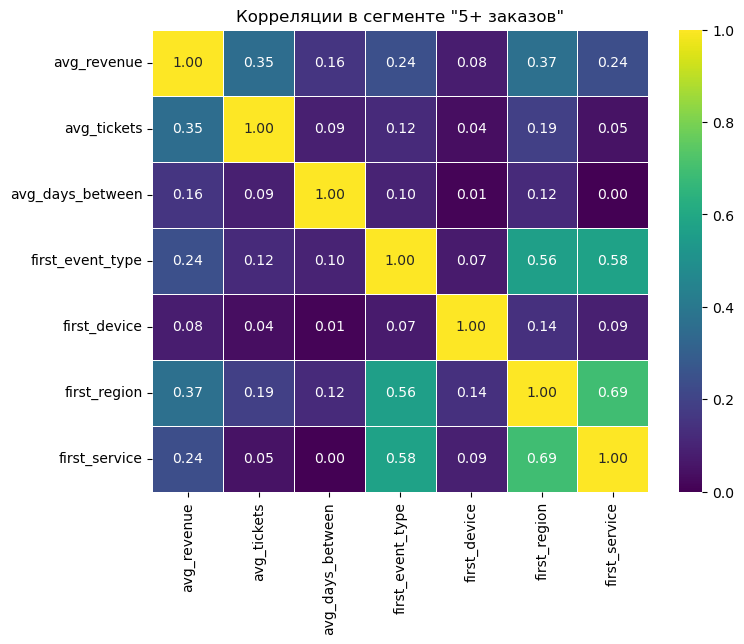

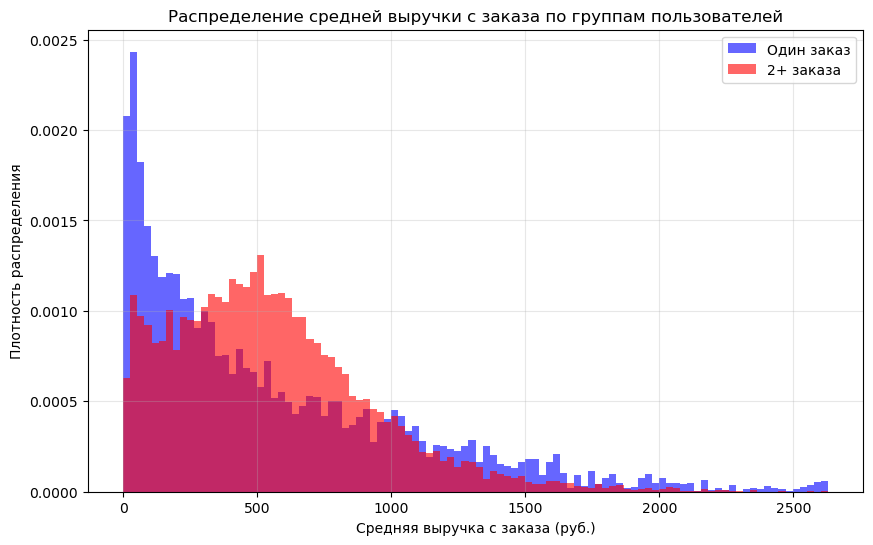

In [90]:
# Разделяем данные на две группы
one_order = user_profile[~user_profile['is_two']]['avg_revenue'] 
multi_order = user_profile[user_profile['is_two']]['avg_revenue'] 

# Строим гистограммы
plt.figure(figsize=(10, 6))
plt.hist(one_order, bins=100, density=True, alpha=0.6, label='Один заказ', color='blue')
plt.hist(multi_order, bins=100, density=True, alpha=0.6, label='2+ заказа', color='red')

plt.title('Распределение средней выручки с заказа по группам пользователей')
plt.xlabel('Средняя выручка с заказа (руб.)')
plt.ylabel('Плотность распределения')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [69]:
# Посмотрим на описательные статистики групп (1 покупка)
one_order.describe()

count    8318.000000
mean      552.678607
std       519.044834
min         0.070000
25%       141.140000
50%       388.715000
75%       839.520000
max      2628.421739
Name: avg_revenue, dtype: float64

In [70]:
# Более 1 покупки
multi_order.describe()

count    13165.000000
mean       551.810878
std        369.147545
min          0.352000
25%        278.415000
50%        503.268000
75%        751.592298
max       2628.421739
Name: avg_revenue, dtype: float64

**В каких диапазонах средней выручки концентрируются пользователи из каждой группы?**

На гистограммах распределения средней выручки с заказа для двух групп пользователей заметны различия в форме кривых. Для пользователей с одним заказом график имеет более пологую и широкую форму, его основание простирается от значений около `50` рублей и уходит за `1500` рублей, с заметным длинным правым хвостом. Пик плотности приходится на диапазон около `100` руб, однако и для больших значений часть пользователей также велика, что указывает на большую разрозненность значений. Это визуально подтверждает высокую неоднородность группы: здесь есть и очень дешёвые покупки, и редкие, но крайне дорогие (до `2600` рублей).

В группе пользователей с двумя и более заказами гистограмма заметно уже, её пик значительно ниже и смещён вправо – основная масса значений сосредоточена в интервале `350–600` рублей, а правый хвост практически обрывается уже после `1500` рублей. Кривая имеет более выраженную центральную часть и быстро убывает к краям, что визуально подтверждает меньший разброс и большую стабильность чеков. На графике видно, что медиана (вертикальная линия, делящая площадь пополам) у повторных покупателей находится правее, что соответствует численному значению `503` против `389` у одноразовых.

**Есть ли различия между группами?**

Различия между группами проявляются не в средних арифметических чеках, а в структуре распределений. Ключевое отличие — медиана: у повторных покупателей она на `114` рублей выше, что означает, что типичный заказ лояльного пользователя дороже, чем у того, кто купил билеты лишь однажды. При этом покупатели с 1 заказом более разнородны: среди них выше доля как дешёвых покупок, так и экстремально дорогих (правый хвост длиннее). Таким образом, можно заключить, что повторные пользователи тратят больше за один заказ в среднем (по медиане), но делают это более равномерно, без резких скачков. Это говорит о том, что высокая разовая выручка не является показателем возврата, а, скорее, пользователи возвращаются благодаря стабильному качеству сервиса и удобству платформы, а их чеки со временем становятся более предсказуемыми.

---

**Задача 4.2.2.** Сравним распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответим на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


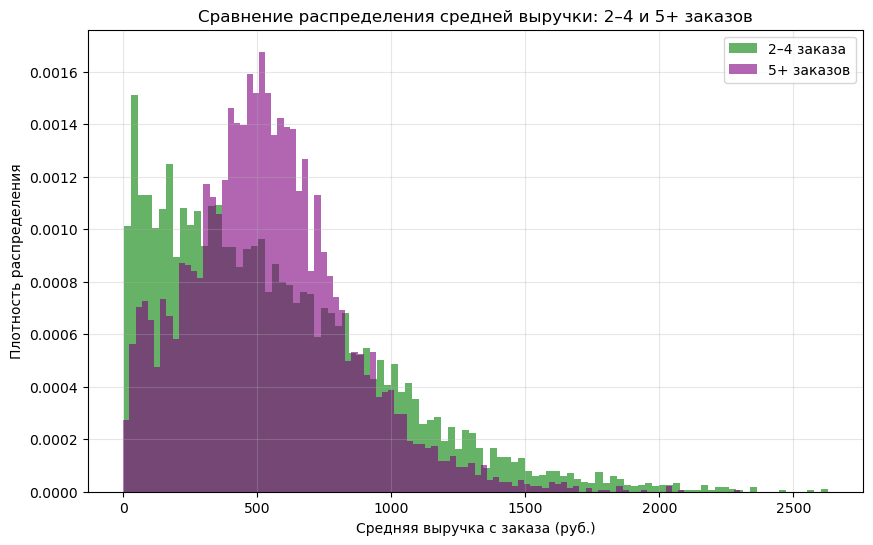

In [91]:
# Разделяем данные на группы
group_2_4 = user_profile[user_profile['is_two'] & ~user_profile['is_five']]['avg_revenue']
group_5_plus = user_profile[user_profile['is_five']]['avg_revenue']

# Строим гистограммы
plt.figure(figsize=(10, 6))
plt.hist(group_2_4, bins=100, density=True, alpha=0.6, label='2–4 заказа', color='green')
plt.hist(group_5_plus, bins=100, density=True, alpha=0.6, label='5+ заказов', color='purple')
plt.title('Сравнение распределения средней выручки: 2–4 и 5+ заказов')
plt.xlabel('Средняя выручка с заказа (руб.)')
plt.ylabel('Плотность распределения')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [72]:
# Описательная статистика группы с 2-4 покупками
group_2_4.describe()

count    7118.000000
mean      557.673770
std       420.043202
min         2.416667
25%       224.187500
50%       477.645427
75%       806.266875
max      2628.421739
Name: avg_revenue, dtype: float64

In [73]:
# Описательная статистика группы с 5+ покупками
group_5_plus.describe()

count    6047.000000
mean      544.909594
std       298.199286
min         0.352000
25%       341.254806
50%       521.755000
75%       710.633247
max      2299.869022
Name: avg_revenue, dtype: float64

Изучив описательные статистики и визуальное представление распределений, можно сделать выводы о различиях между группами пользователей с 2–4 заказами и 5 и более заказами:

На гистограммах отчётливо видно, что распределение средней выручки у группы 5+ заказов смещено вправо и имеет более острый пик по сравнению с группой 2–4 заказа. Основная масса значений в группе 5+ пользователей концентрируется в диапазоне примерно 400–`700` рублей, причём пик плотности приходится на значения около `500` рублей, что согласуется с медианой `521,76`. Распределение выглядит более симметричным и компактным, правый хвост практически отсутствует — после 1500 рублей плотность быстро сходит на нет.

В группе 2–4 заказа гистограмма шире: её основание простирается от очень низких значений (ниже `100` рублей) до примерно `800` рублей, с более пологим скатом и длинным правым хвостом, уходящим за `1500` рублей. Пик плотности приходится на меньшие значения — около `400` рублей (медиана `477,65`), и распределение скошено вправо за счёт редких, но очень крупных покупок. 

Таким образом, визуальный анализ полностью согласуется с цифрами: активные пользователи (5+ заказов) имеют более высокий типичный чек, меньший разброс и практически не совершают экстремально дешёвых или дорогих покупок. Их поведение стабильно и предсказуемо, что свидетельствует о сформировавшейся привычке покупать билеты в определённом ценовом сегменте. Пользователи с умеренным числом заказов (2–4) более разнородны: среди них есть как те, кто покупает очень дешевые билеты, так и те, кто тратит крупные суммы, но редко. Наиболее лояльные клиенты — это не те, кто делает редкие крупные покупки, а те, кто регулярно приобретает билеты по стабильной, немного выше средней цене. Их поведение более предсказуемо, и они представляют собой наиболее ценную с точки зрения регулярности аудиторию.



---

**Задача 4.2.3.** Проанализируем влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучим распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишем основные наблюдения.
- Разделим пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитаем общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответим на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

Для начала разделим пользователей на сегменты:

In [74]:
#Создаем копию, чтобы убрать пердупреждение
user_profile = user_profile.copy()

# Разбиваем на сегменты по количеству билетов в заказе
user_profile['tickets_segment'] = pd.cut(
    user_profile['avg_tickets'], 
    bins=[0, 2, 3, 5, float('inf')], 
    labels=['1–2 билета', '2–3 билета', '3–5 билетов', '5+ билетов'],
    right=False)

# Датафрейм со статистикой
tickets_segment_stats = user_profile.groupby('tickets_segment').agg(
    total_users=('user_id', 'count'),
    is_two_users=('is_two', 'sum')
).reset_index()

# Доля пользователей, совершивших повторные заказы
tickets_segment_stats['is_two_ratio'] = tickets_segment_stats['is_two_users'] / tickets_segment_stats['total_users'] *100

# Просмотр содержимого
tickets_segment_stats

C:\Users\User\AppData\Local\Temp\ipykernel_26128\3375885585.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tickets_segment_stats = user_profile.groupby('tickets_segment').agg(


,tickets_segment,total_users,is_two_users,is_two_ratio
0,1–2 билета,2391,1224,51.191970
1,2–3 билета,9411,6914,73.467219
2,3–5 билетов,9024,4903,54.332890
3,5+ билетов,657,124,18.873668


Теперь визуализируем полученные результаты:

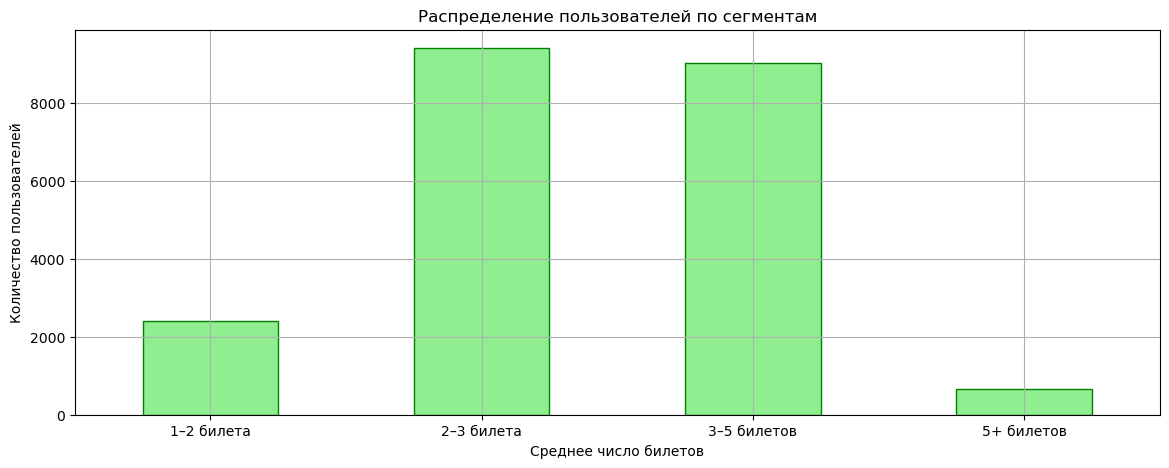

In [101]:
# Количество пользователей по сегментам
tickets_segment_stats.plot(
    kind='bar',
    x='tickets_segment',      
    y='total_users',           
    rot=0,
    legend=False,
    title='Распределение пользователей по сегментам',
    figsize=(14,5),
    edgecolor='green',
    color='lightgreen',
    xlabel='Среднее число билетов',
    ylabel='Количество пользователей',
    grid = True
)

plt.show()

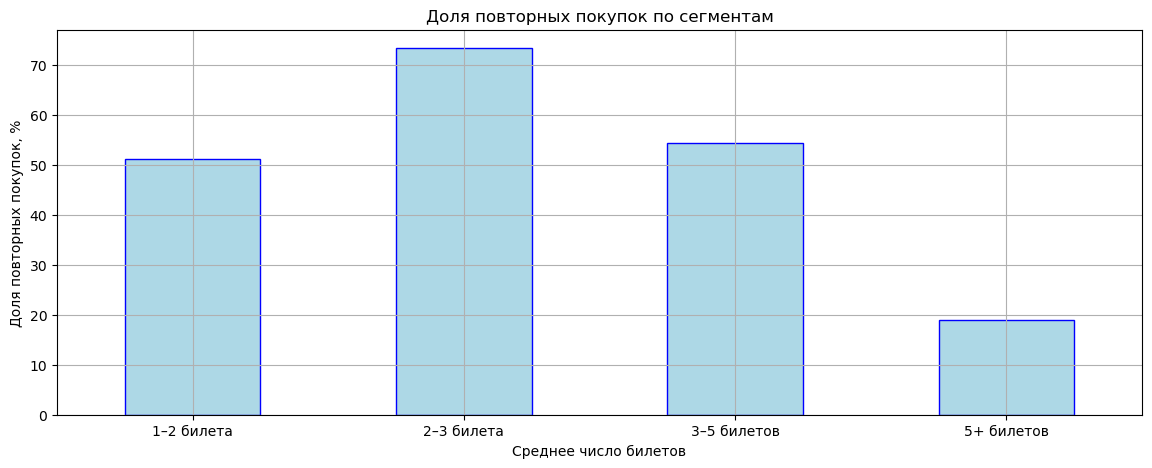

In [100]:
# Доля повторных покупок
tickets_segment_stats.plot(
    kind='bar',
    x='tickets_segment',      
    y='is_two_ratio',           
    rot=0,
    legend=False,
    title='Доля повторных покупок по сегментам',
    figsize=(14,5),
    edgecolor='blue',
    color='lightblue',
    xlabel='Среднее число билетов',
    ylabel='Доля повторных покупок, %',
    grid = True
)

plt.show()

Анализ распределения пользователей по сегментам среднего количества билетов в заказе показывает сильную концентрацию в двух сегментах: более `85%` пользователей (`9620` и `9032` из `21700`) попадают в группы 2–3 билета и 3–5 билетов. Сегмент 1–2 билета заметно меньше (`2391`), а сегмент 5+ билетов еще более малочисленен (`657`). Таким образом, распределение неравномерное, т.к. основная масса пользователей покупает от 2 до 5 билетов за один заказ.

Доля повторных покупок также сильно отличается между сегментами. Самый высокий показатель зафиксирован в сегменте 2–3 билета – `74.0%`, что значительно выше среднего по выборке (`61.7%`). Это аномально высокий уровень лояльности. Напротив, сегмент 5+ билетов демонстрирует крайне низкую долю – всего `18.9%`, что также является явным выбросом вниз. Промежуточные сегменты (1–2 билета и 3–5 билетов) показывают доли около `51–54%`, что ниже среднего, но не критично.

Таким образом, количество билетов в заказе является значимым фактором, влияющим на возврат пользователей. Наиболее ценными с точки зрения удержания являются пользователи, покупающие в среднем 2–3 билета – они возвращаются чаще всего. Пользователи с очень большим числом билетов (5+) практически не возвращаются, что может указывать на разовые групповые или корпоративные заказы, не предполагающие повторных покупок. Для повышения лояльности стоит сосредоточить усилия на сегменте 2–3 билета, а также проанализировать причины низкого возврата в сегменте 5+ и, возможно, предложить им специальные условия для повторных заказов.


---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучим временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируем, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделим день недели.
- Для каждого дня недели подсчитаем общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируем.
- Ответим на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


Для начала подготовим данные и разделим их на группы:

In [77]:
# Извлекаем день недели (0 - понедельник, 6 - воскресенье)
user_profile['first_weekday'] = user_profile['first_order_dt'].dt.weekday

# Названия дней недели
weekday_names = {
    0: 'Пн', 1: 'Вт', 2: 'Ср', 3: 'Чт',
    4: 'Пт', 5: 'Сб', 6: 'Вс'}
user_profile['first_weekday_name'] = user_profile['first_weekday'].map(weekday_names)

# Группировка
weekday_stats = user_profile.groupby('first_weekday_name').agg(
    total_users=('user_id', 'count'),
    is_two_users=('is_two', 'sum')
).reset_index()

#  Процент пользователей, совершивших повторные заказы
weekday_stats['is_two_ratio'] = weekday_stats['is_two_users'] / weekday_stats['total_users']*100

# Сортировка по порядку дней недели
weekday_stats['first_weekday_name'] = pd.Categorical(
    weekday_stats['first_weekday_name'], 
    categories=['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс'], 
    ordered=True
)
weekday_stats = weekday_stats.sort_values('first_weekday_name')

# Выводим на экран
weekday_stats

,first_weekday_name,total_users,is_two_users,is_two_ratio
2,Пн,2901,1817,62.633575
1,Вт,3157,1949,61.735825
5,Ср,3048,1895,62.171916
6,Чт,3098,1843,59.489994
3,Пт,3230,1935,59.907121
4,Сб,3292,2067,62.788578
0,Вс,2757,1659,60.174102


Визуализируем полученные результаты:

In [78]:
# Количество пользователей по дням недели
weekday_stats.plot(
    kind='bar',
    x='first_weekday_name',      
    y='total_users',           
    rot=0,
    legend=False,
    title='Количество первых покупок по дням недели',
    figsize=(14,5),
    edgecolor='green',
    color='lightgreen',
    xlabel='День недели',
    ylabel='Количество пользователей',
    grid = True
)


<Axes: title={'center': 'Количество первых покупок по дням недели'}, xlabel='День недели', ylabel='Количество пользователей'>

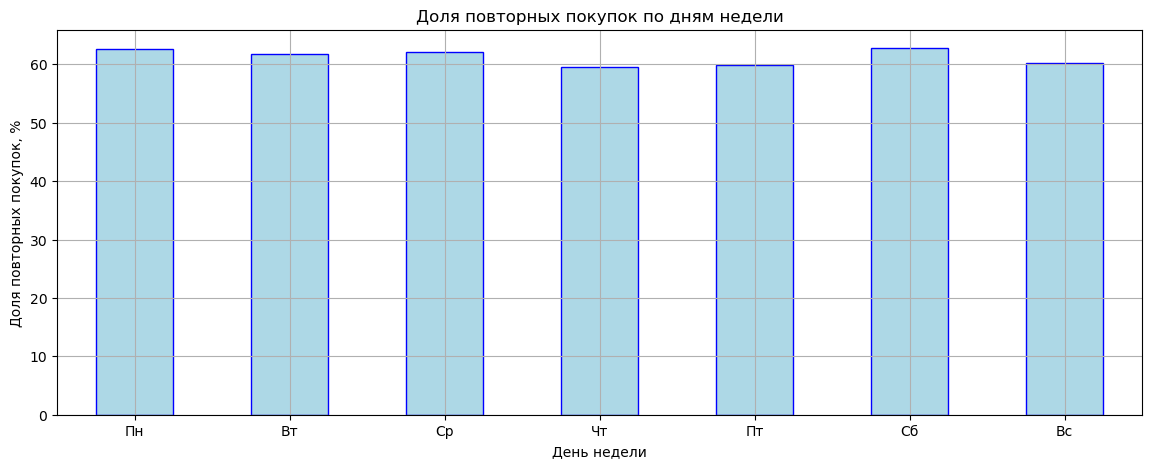

In [99]:
# Доля повторных покупок
weekday_stats.plot(
    kind='bar',
    x='first_weekday_name',      
    y='is_two_ratio',           
    rot=0,
    legend=False,
    title='Доля повторных покупок по дням недели',
    figsize=(14,5),
    edgecolor='blue',
    color='lightblue',
    xlabel='День недели',
    ylabel='Доля повторных покупок, %',
    grid = True
)
plt.show()

Анализ распределения первых покупок по дням недели показывает, что наибольшее число новых пользователей приходит в пятницу и субботу (`3232` и `3424` соответственно), это значит, что люди чаще планируют мероприятия на выходные. Наименьшее количество первых заказов зафиксировано в воскресенье (`2791`), что может быть связано с окончанием выходных.

Доля пользователей, совершивших повторные заказы, варьируется в узком диапазоне от `59.6%` (четверг) до `64.2%` (суббота). Разница между максимальным и минимальным значением составляет около `4.6` процента, что не является существенным отклонением на фоне общего среднего уровня возврата (`61.7%`). Наиболее высокий возврат наблюдается у пользователей, впервые купивших билеты в субботу (`64.2%`), а самый низкий – в четверг (`59.6%`), однако эти различия скорее можно считать случайными колебаниями.

Таким образом, день недели первой покупки не является значимым фактором, определяющим вероятность повторного заказа. Пользователи, пришедшие в любой день недели, возвращаются примерно с одинаковой вероятностью. Это означает, что маркетинговые усилия по привлечению новых клиентов могут быть равномерно распределены по всем дням недели без потери эффективности в удержании. Если и есть небольшие различия, они, скорее всего, связаны с особенностями конкретной выборки, а не с устойчивой закономерностью. 



---

**Задача 4.3.2.** Изучим, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитаем среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуем, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


In [80]:
# Разделяем данные на группы
group_2_4 = user_profile[user_profile['is_two'] & ~user_profile['is_five']]['avg_days_between']
group_5_plus = user_profile[user_profile['is_five']]['avg_days_between']

In [81]:
# Описательная статистика для группы 2-4
group_2_4.describe()

count    7118.000000
mean       21.219315
std        28.339822
min         0.000000
25%         0.000000
50%         9.000000
75%        33.500000
max       148.000000
Name: avg_days_between, dtype: float64

In [82]:
# Описательная статистика для группы 5+
group_5_plus.describe()

count    6047.000000
mean        9.890956
std         7.786247
min         0.000000
25%         3.895946
50%         8.111111
75%        14.125000
max        37.500000
Name: avg_days_between, dtype: float64

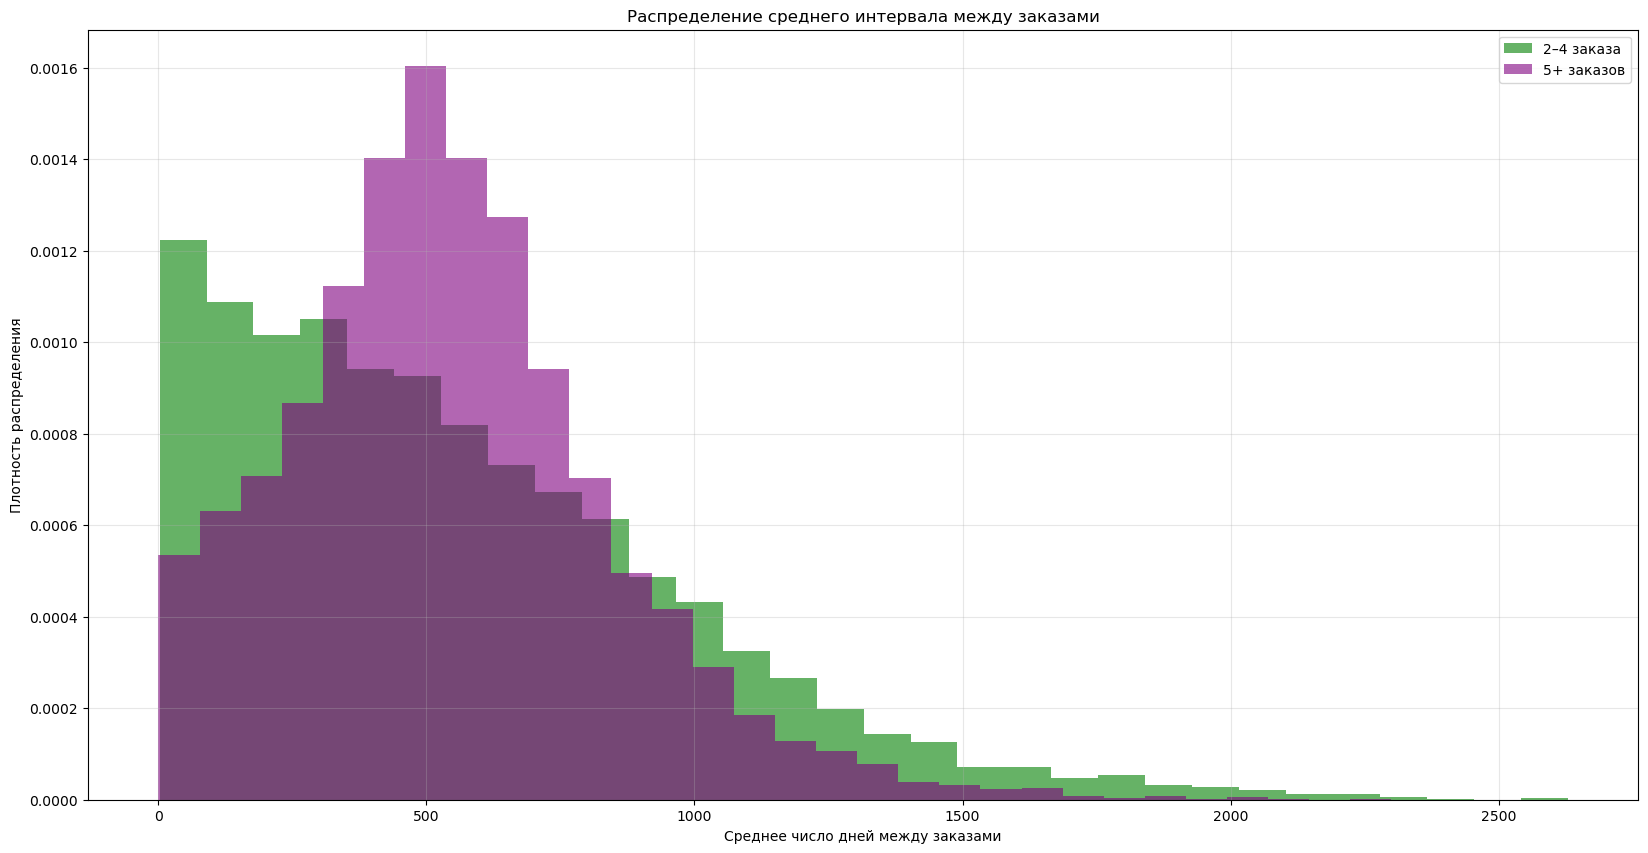

In [98]:
# Строим гистограммы
plt.figure(figsize=(20, 10))
plt.hist(group_2_4, bins=30, density=True, alpha=0.6, label='2–4 заказа', color='green')
plt.hist(group_5_plus, bins=30, density=True, alpha=0.6, label='5+ заказов', color='purple')
plt.title('Распределение среднего интервала между заказами')
plt.xlabel('Среднее число дней между заказами')
plt.ylabel('Плотность распределения')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_26128\518930909.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([group_2_4.dropna(), group_5_plus.dropna()],


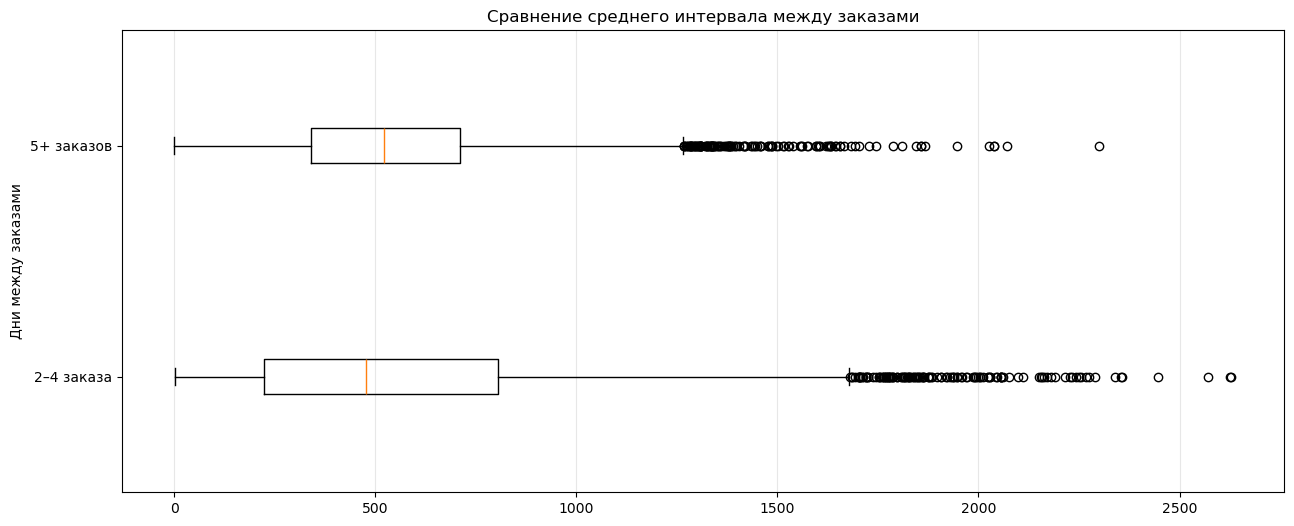

In [97]:
# boxplot для сравнения
plt.figure(figsize=(15, 6))
plt.boxplot([group_2_4.dropna(), group_5_plus.dropna()], 
            labels=['2–4 заказа', '5+ заказов'],
            vert=False)
plt.title('Сравнение среднего интервала между заказами')
plt.ylabel('Дни между заказами')
plt.grid(axis='x', alpha=0.3)
plt.show()

Анализ распределения среднего интервала между заказами для двух групп пользователей на основе гистограмм, описательных статистик и ящиков с усами показывает следующие различия:

Для группы 2–4 заказа распределение имеет широкий размах: значения варьируются от 0 до 148 дней, при этом межквартильный размах составляет `0–33.5` дня, а медиана равна `9` дням. Гистограмма демонстрирует длинный правый хвост: основная масса значений сконцентрирована в диапазоне до `20` дней, но присутствует заметная доля пользователей с интервалами более `50` дней, что подтверждается высоким стандартным отклонением (`28.3`). Диаграмма размаха показывает множество выбросов в верхней части, что указывает на неоднородность поведения пользователей. Часть пользователей возвращается быстро, а другие с большими паузами.

Для группы 5+ заказов распределение существенно более компактное: интервалы лежат в пределах от `0` до `37.5` дней, межквартильный размах уже (`3.4–13.8`) дня, а медиана составляет `7.75` дня. Гистограмма имеет острый пик в районе `0–10` дней и быстро спадает, правый хвост практически отсутствует. Стандартное отклонение (`7.8`) в `3.6` раза меньше, чем в предыдущей группе, что говорит о высокой регулярности покупок. На ящике с усами выбросов почти нет, распределение симметричное.

Таким образом, средний интервал между заказами сильно отличается в зависимости от группы пользователей: суперактивные пользователи (5+ заказов) возвращаются значительно чаще (медиана `7.75` против `9` дней) и стабильнее, что свидетельствует о сформировавшейся привычке пользоваться сервисом. Пользователи с 2–4 заказами ведут себя менее предсказуемо: они могут возвращаться как на следующий день, так и спустя месяцы. Для бизнеса это означает, что сокращение времени между покупками — ключевой фактор перехода пользователя в категорию лояльных. Стратегии удержания должны быть направлены на стимулирование частоты возвратов (например, персонализированные рекомендации, напоминания о предстоящих событиях, бонусы за регулярность), чтобы сместить распределение интервалов влево и увеличить долю пользователей с короткими циклами покупок.

---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучим, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используем универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведем корреляционный анализ:
- Рассчитаем коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используем параметр `interval_cols` для определения интервальных данных.
- Проанализируем полученные результаты. Если полученные значения будут близки к нулю, проверим разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделим сегменты пользователей по полю `total_orders`, а затем повторим корреляционный анализ. Выделим такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируем результат корреляции с помощью тепловой карты.
- Ответим на вопрос: какие признаки наиболее связаны с количеством заказов?

---

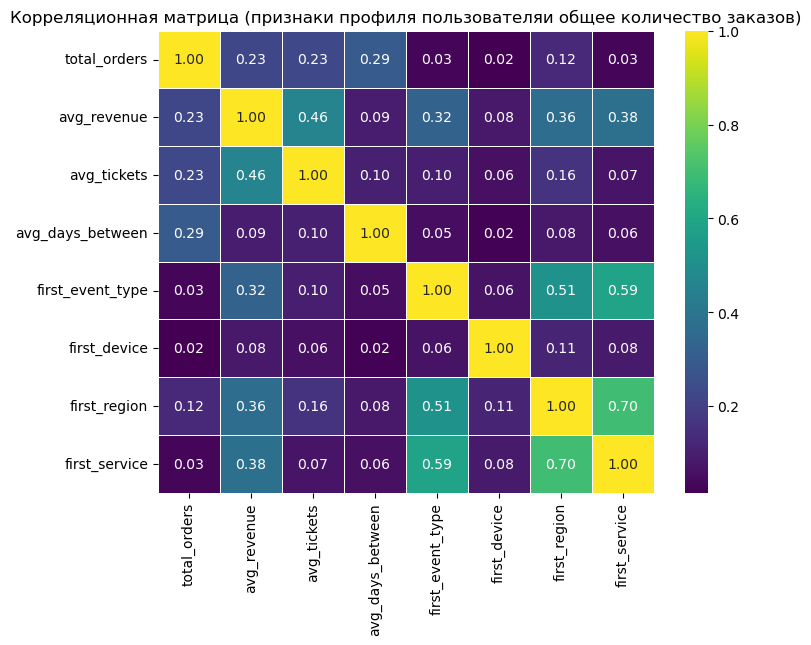

In [96]:
# Выбираем признаки для корреляции
features = ['total_orders', 'avg_revenue', 'avg_tickets', 'avg_days_between',
            'first_event_type', 'first_device', 'first_region', 'first_service']

# Рассчитываем phi_k матрицу
phik_matrix = user_profile[features].phik_matrix(
    interval_cols=['total_orders', 'avg_revenue', 'avg_tickets', 'avg_days_between'])

# Визуализация тепловой карты
plt.figure(figsize=(8, 6))
sns.heatmap(phik_matrix, annot=True, cmap='viridis', fmt='.2f', linewidths=0.5)
plt.title('Корреляционная матрица (признаки профиля пользователяи общее количество заказов)')
plt.show()

В исходной матрице phi_k коэффициенты корреляции между total_orders и другими признаками близки к нулю. Это может быть связано с тем, что в данных преобладает одна группа пользователей, скорее всего, большое число пользователей с одним заказом. Когда одна категория доминирует, коэффициент корреляции теряет чувствительность и показывает отсутствие связей, даже если внутри остальных групп зависимости существуют.

Чтобы выявить скрытые взаимосвязи, разобьем пользователей на три сегмента по числу заказов:

- 1 заказ;

- 2–4 заказа;

- 5+ заказов.


In [95]:
# Признаки для анализа (без total_orders)
features = ['avg_revenue', 'avg_tickets', 'avg_days_between',
            'first_event_type', 'first_device', 'first_region', 'first_service']

# Создаём копию и добавляем сегмент
user_profile_seg = user_profile.copy()
user_profile_seg['orders_segment'] = pd.cut(
    user_profile_seg['total_orders'],
    bins=[1, 2, 5, float('inf')],
    labels=['1 заказ', '2–4 заказа', '5+ заказов'],
    right=False
)

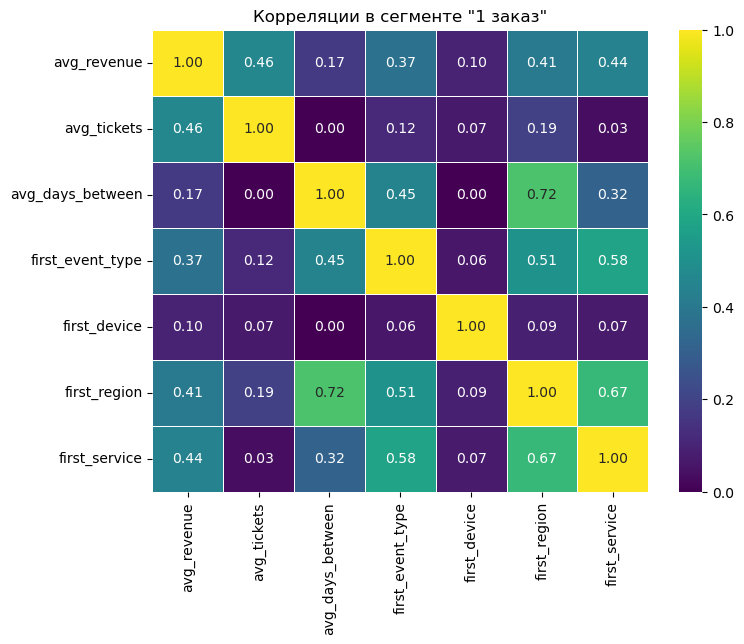

In [94]:
# Визуализация для сегмента с 1 заказом
data_seg = user_profile_seg[user_profile_seg['orders_segment'] == '1 заказ'][features]
phi_matrix = data_seg.phik_matrix(interval_cols=['avg_revenue', 'avg_tickets', 'avg_days_between'])
plt.figure(figsize=(8,6))
sns.heatmap(phi_matrix, annot=True, cmap='viridis', fmt='.2f', linewidths=0.5)
plt.title('Корреляции в сегменте "1 заказ"')
plt.show()

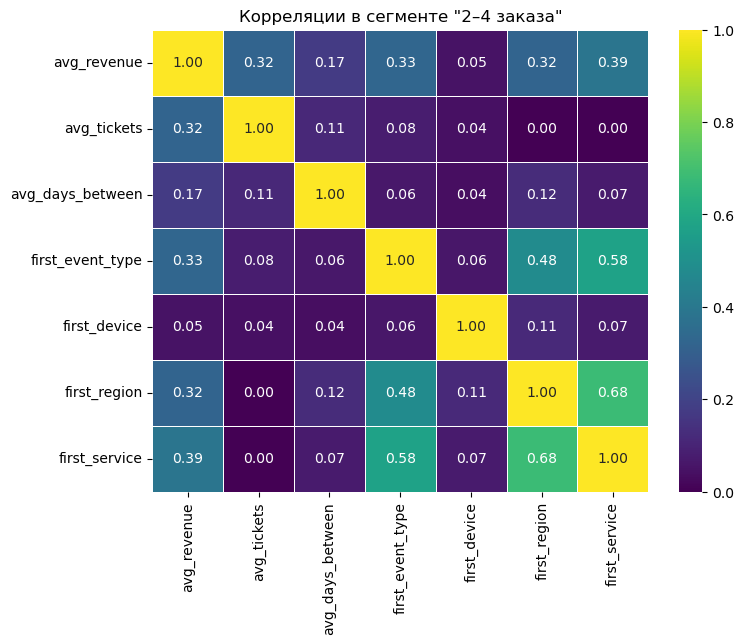

In [93]:
# Визуализация для сегмента с 2-4 заказами
data_seg = user_profile_seg[user_profile_seg['orders_segment'] == '2–4 заказа'][features]
phi_matrix = data_seg.phik_matrix(interval_cols=['avg_revenue', 'avg_tickets', 'avg_days_between'])
plt.figure(figsize=(8,6))
sns.heatmap(phi_matrix, annot=True, cmap='viridis', fmt='.2f', linewidths=0.5)
plt.title('Корреляции в сегменте "2–4 заказа"')
plt.show()

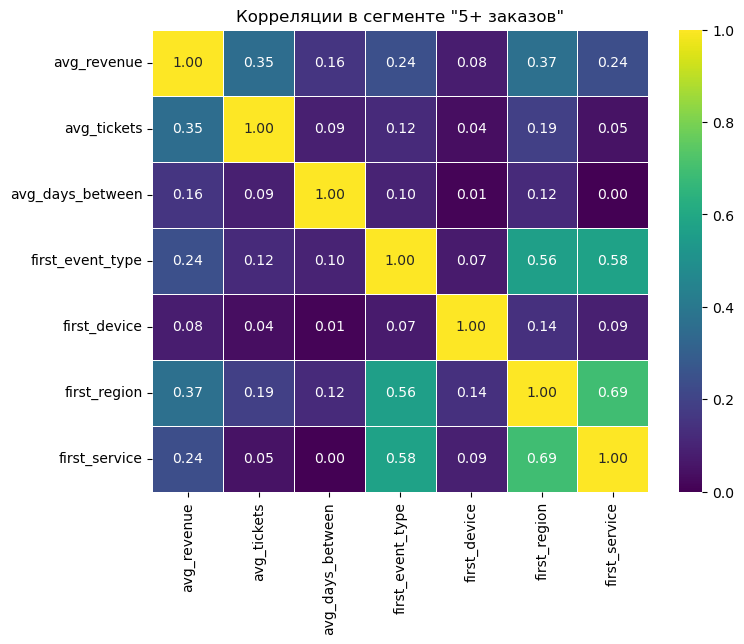

In [92]:
# Визуализация для сегмента с 5+ заказов
data_seg = user_profile_seg[user_profile_seg['orders_segment'] == '5+ заказов'][features]
phi_matrix = data_seg.phik_matrix(interval_cols=['avg_revenue', 'avg_tickets', 'avg_days_between'])
plt.figure(figsize=(8,6))
sns.heatmap(phi_matrix, annot=True, cmap='viridis', fmt='.2f', linewidths=0.5)
plt.title('Корреляции в сегменте "5+ заказов"')
plt.show()

Анализ корреляционных матриц показывает, что наиболее значимая связь с числом заказов наблюдается у признака `avg_days_between` (коэффициент `0.29` в общей матрице, хотя в сегментах его влияние проявляется иначе). Это означает, что чем меньше средний интервал между покупками, тем больше заказов совершает пользователь.

Далее рассмотрим каждый сегмент по отдельности:

Сегмент «1 заказ»: интересно, что внутри этого сегмента `avg_revenue` сильно коррелирует с `avg_tickets` (`0.46`) – чем больше билетов, тем выше выручка, что логично. Также заметна связь `first_region` и `first_service` (`0.67`), что говорит о региональной привязке операторов.

Сегмент «2–4 заказа»: появляется умеренная связь `avg_revenue` с `first_event_type` (`0.33`) и `first_service` (`0.39`). Это может означать, что тип первого мероприятия и оператор влияют на сумму среднего чека в этой группе. Связь `avg_days_between` с другими признаками остаётся слабой (`0.06–0.17`).

Сегмент «5+ заказов»: корреляции между `avg_revenue` и `avg_tickets` усиливаются (`0.35`). При этом `avg_days_between` слабо коррелирует с `avg_revenue` (`0.16`) и практически не связан с категориальными признаками. Это говорит о том, что активные пользователи становятся более однородными – их поведение меньше зависит от начальных характеристик.

Таким образом, `avg_days_between` – главный фактор, влияющий на количество заказов. Чем чаще пользователь возвращается, тем выше общее число покупок.

`avg_revenue` и `avg_tickets` коррелируют друг с другом, но их связь с `total_orders` умеренная и нелинейная.

Категориальные признаки (`first_event_type`, `first_region`, `first_service`) имеют заметную связь с `total_orders` только в сегменте 2–4 заказа, где они могут влиять на переход пользователя в категорию активных. Однако в целом их вклад в итоговое число заказов невелик.

Так, для увеличения числа заказов ключевым направлением является сокращение времени между покупками. Маркетинговые усилия стоит направлять на стимулирование частоты возвратов (рекомендации, напоминания, программы лояльности). Категориальные признаки могут быть полезны в сегменте 2–4 заказа. Зная, с какого мероприятия, региона и оператора начал пользователь, мы можем предлагать ему именно то, что ему интересно, и тем самым стимулировать его перейти из категории умеренно активных (2-4 заказа) в активных (5+ заказов).

### 5. Общий вывод и рекомендации

В конце проекта напишем общий вывод и рекомендации: расскажем заказчику, на что нужно обратить внимание. В выводах кратко укажем:

- **Информацию о данных**, с которыми мы работали, и то, как они были подготовлены: например, о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополним выводы информацией, которая покажется важной и интересной.

В конце предложим заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажем, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

В ходе работы был проведён анализ данных о покупках пользователей Яндекс Афиши. Исходный датасет включал `290 611` заказов, из которых после фильтрации по 99-му перцентилю и удаления отрицательной выручки было отобрано `281 879` записей. Выручка в тенге пересчитана в рубли по актуальному курсу, пропуски в `days_since_prev` оставлены как естественное отсутствие повторных покупок. На основе этих данных сформирован профиль для `21 700` уникальных пользователей.

**Основные результаты:**

Доля пользователей, совершивших 2+ заказа — `61.7%`, 5+ заказов — `28.9%`. Это говорит о том, что платформа успешно удерживает значительную часть аудитории.

Средняя выручка с заказа — `552` руб., медианный чек у повторных пользователей (`503` руб.) выше, чем у одноразовых (`389` руб.). Это указывает на то, что лояльная аудитория тратит больше за один заказ, но делает это более стабильно.

Основные точки входа: концерты (`44.7%` первых покупок), мобильные устройства (`82.9%`), Каменевский регион (`32.5%` пользователей), оператор «Билеты без проблем» (`23.1%`).

Влияние дня недели на возврат незначителем (разброс `59.5%` – `64.2%`).

Ключевой фактор, влияющий на общее число заказов — средний интервал между покупками: чем он короче, тем выше число заказов (коэффициент корреляции `0.29`).

Самая высокая доля возврата зафиксирована в сегменте пользователей с 2–3 билетами в заказе — `74%`. Напротив, пользователи с 5+ билетами почти не возвращаются (`18.9%`), что может указывать на разовые корпоративные или групповые заказы.

**Рекомендации:**

Стимулируйте частоту возвратов. Основной рычаг увеличения числа заказов — сокращение времени между покупками. Внедрите персонализированные push-уведомления о предстоящих событиях, программы лояльности с бонусами за регулярность, промокоды или акции для пользователей, которые не возвращались более 2 недель.

Сосредоточьте маркетинговые усилия на сегменте 2–4 заказа. Именно эти пользователи имеют наибольший потенциал перехода в категорию суперактивных (5+). Используйте данные о первом заказе (тип мероприятия, регион, оператор) для персонализированных предложений — например, если пользователь начинал с концертов, предлагайте ему похожие события со скидкой при повторной покупке.

Удерживайте активных пользователей (5+ заказов). Их поведение стабильно и предсказуемо — они привыкли к сервису. Важно поддерживать для них широкий ассортимент событий и высокое качество обслуживания, чтобы они не переключались на конкурентов.

Обратите внимание на региональное развитие. Несмотря на доминирование двух крупных регионов, в большинстве других регионов активность низкая. Проведите дополнительные исследования, чтобы понять причины — возможно, там недостаточно мероприятий или слабая рекламная поддержка. Инвестиции в развитие этих регионов могут дать прирост новых пользователей.

Сделайте ставку на мобильный интерфейс. `83%` первых покупок совершается с мобильных устройств. Оптимизация мобильного приложения и мобильной версии сайта — приоритетная задача.

Анализируйте сегмент с большим числом билетов (5+). Эти пользователи почти не возвращаются, но их заказы могут приносить высокую разовую выручку. Возможно, для них стоит разработать специальные условия или программы для корпоративных клиентов, чтобы стимулировать повторные заказы.

### 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

**Вставьте ссылку на проект в этой ячейке тетрадки перед отправкой проекта на ревью.**